# 📝 Portfolio Audit and Expected Loss Calculation

The data can be downloaded here: https://www.kaggle.com/datasets/db0boy/lending-club-loan-data-cleared/data

## 📩 Internal Memorandum

From: Chief Risk Officer (CRO)

To: Data Science & Risk Team

Subject: Valuation of the "Lending Club" portfolio for acquisition.

Our institution is evaluating the purchase of a consumer loan portfolio originated by the Lending Club platform. The Investment team is enthusiastic because the interest rates on these loans appear highly profitable. However, from the Risk department—and under the regulator's close scrutiny—we know that profitability means nothing if we cannot estimate the actual risk of default and the resulting economic loss.

I will not approve this purchase based on intuition. I need you to build a credit scoring and Expected Loss valuation engine from scratch.

To do this, you will need to calculate the fundamental credit risk formula:
Expected Loss (EL) = PD × LGD × EAD

### 📐 Expected Loss (EL) Estimation

To calculate the actual economic loss of the consumer portfolio, we apply the fundamental credit risk formula:

* **Probability of Default (PD):** Estimated using the output probability from our classification models (such as `predict_proba()` from Logistic Regression or RandomForest).
* **Loss Given Default (LGD):** Calculated based on the previously modeled `Loss` variable (capped at 300% for business consistency). It represents the proportion of the balance that the institution fails to recover once a default occurs.
* **Exposure at Default (EAD):** In this portfolio, this is approximated using the `funded_amnt` variable (funded amount) or the outstanding balance.


In [85]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Métricas
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [86]:
# Predictor covariates
df= pd.read_csv('/Users/danielmercedes/Documents/Jyts/Lending_Club/X.csv')

# Delinquent/NON-delinquent variable
y = pd.read_csv('/Users/danielmercedes/Documents/Jyts/Lending_Club/target.csv')

In [87]:
y.value_counts()

y
0    1859927
1     279716
Name: count, dtype: int64

In [88]:
y.isnull().sum()

y    0
dtype: int64

In [89]:
df.isnull().sum()

funded_amnt                                 0
interest_rate                               0
monthly_payment                             0
grade                                       0
emp_title                              148527
emp_length                             130346
home_ownership_status                       0
annual_income                               0
verification_status                         0
loan_purpose                                0
addr_state                                  0
dept_paym_income_ratio                      0
num_30+_delinq_in_2yrs                      0
num_inq_in_6mths                            0
mths_since_last_delinq                1090997
num_open_credit_lines                       0
num_derogatory_pub_rec                      0
total_credit_revolving_bal                  0
used_credit_share                           0
tot_num_credit_lines                        0
initial_list_status                         0
remaining_princ_for_tot_amnt_fund 

In [90]:
pd.set_option('display.max_columns', None)
df.head(10)

,funded_amnt,interest_rate,monthly_payment,grade,emp_title,emp_length,home_ownership_status,annual_income,verification_status,loan_purpose,addr_state,dept_paym_income_ratio,num_30+_delinq_in_2yrs,num_inq_in_6mths,mths_since_last_delinq,num_open_credit_lines,num_derogatory_pub_rec,total_credit_revolving_bal,used_credit_share,tot_num_credit_lines,initial_list_status,remaining_princ_for_tot_amnt_fund,paym_rec_for_tot_amnt_fund,princ_rec,interest_rec,late_fees_rec,num_open_trades_in_6mths,num_installment_acc_op_in_12mths,num_installment_acc_op_in_24mths,mths_since_last_installment_acc_op,num_rev_trades_op_in_12mths,num_rev_trades_op_in_24mths,max_bal_owed,bal_to_cred_lim,num_inq,num_inq_in_12mths,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,disbursement_method,loan_term_months,issue_date_month,issue_date_year,region_code,earliest_cr_line_month,earliest_cr_line_year
0,2500,13.56,84.92,C1,Chef,10+ years,RENT,55000.0,Not Verified,debt_consolidation,NY,18.24,0,1,NaN,9,1,4341,10.3,34,w,2386.02,167.02,113.98,53.04,0.0,2.0,1.0,2.0,2.0,2.0,7.0,2137.0,28.0,1.0,2,NaN,NaN,Cash,36,Dec,2018,1,Apr,2001
1,30000,18.94,777.23,D2,Postmaster,10+ years,MORTGAGE,90000.0,Source Verified,debt_consolidation,LA,26.52,0,0,71.0,13,1,12315,24.2,44,w,29387.75,1507.11,612.25,894.86,0.0,4.0,2.0,3.0,3.0,4.0,5.0,998.0,57.0,2.0,2,NaN,NaN,Cash,60,Dec,2018,7,Jun,1987
2,5000,17.97,180.69,D1,Administrative,6 years,MORTGAGE,59280.0,Source Verified,debt_consolidation,MI,10.51,0,0,NaN,8,0,4599,19.1,13,w,4787.21,353.89,212.79,141.10,0.0,0.0,0.0,2.0,14.0,0.0,2.0,0.0,35.0,1.0,0,NaN,NaN,Cash,36,Dec,2018,4,Apr,2011
3,4000,18.94,146.51,D2,IT Supervisor,10+ years,MORTGAGE,92000.0,Source Verified,debt_consolidation,WA,16.74,0,0,NaN,10,0,5468,78.1,13,w,3831.93,286.71,168.07,118.64,0.0,1.0,3.0,5.0,5.0,0.0,0.0,3761.0,70.0,2.0,3,NaN,NaN,Cash,36,Dec,2018,9,Feb,2006
4,30000,16.14,731.78,C4,Mechanic,10+ years,MORTGAGE,57250.0,Not Verified,debt_consolidation,MD,26.35,0,0,NaN,12,0,829,3.6,26,w,29339.02,1423.21,660.98,762.23,0.0,3.0,3.0,5.0,4.0,2.0,4.0,516.0,54.0,1.0,0,NaN,NaN,Cash,60,Dec,2018,2,Dec,2000
5,5550,15.02,192.45,C3,Director COE,10+ years,MORTGAGE,152500.0,Not Verified,credit_card,IN,37.94,0,3,NaN,18,0,53854,48.1,44,w,5302.50,377.95,247.50,130.45,0.0,1.0,2.0,3.0,4.0,1.0,4.0,17584.0,58.0,2.0,6,NaN,NaN,Cash,36,Dec,2018,4,Sep,2002
6,2000,17.97,72.28,D1,Account Manager,4 years,RENT,51000.0,Source Verified,debt_consolidation,IL,2.40,0,1,NaN,1,0,0,0.0,9,w,1914.71,141.56,85.29,56.27,0.0,0.0,2.0,3.0,7.0,0.0,1.0,0.0,100.0,0.0,1,NaN,NaN,Cash,36,Dec,2018,6,Nov,2004
7,6000,13.56,203.79,C1,Assistant Director,10+ years,RENT,65000.0,Source Verified,credit_card,IN,30.10,0,0,NaN,19,0,38476,69.3,37,w,5864.01,201.53,135.99,65.54,0.0,0.0,0.0,1.0,23.0,0.0,2.0,9413.0,74.0,1.0,0,NaN,NaN,DirectPay,36,Dec,2018,4,Nov,1997
8,5000,17.97,180.69,D1,Legal Assistant III,10+ years,MORTGAGE,53580.0,Source Verified,debt_consolidation,FL,21.16,0,1,32.0,8,0,8018,35.2,38,w,4786.79,353.89,213.21,140.68,0.0,5.0,5.0,5.0,3.0,1.0,6.0,3132.0,73.0,2.0,4,33.0,32.0,Cash,36,Dec,2018,3,Aug,1998
9,6000,14.47,206.44,C2,NaN,< 1 year,OWN,300000.0,Not Verified,debt_consolidation,CT,17.43,1,1,17.0,38,0,65950,49.8,58,w,5730.20,405.64,269.80,135.84,0.0,1.0,1.0,3.0,7.0,1.0,12.0,15926.0,48.0,2.0,2,NaN,17.0,Cash,36,Dec,2018,0,Apr,2002


In [91]:
df['emp_title'].unique()

<StringArray>
[                               'Chef',                         'Postmaster ',
                      'Administrative',                       'IT Supervisor',
                            'Mechanic',                        'Director COE',
                     'Account Manager',                  'Assistant Director',
                 'Legal Assistant III',                                   nan,
 ...
                     'Shipping/loader',       'Raw/Finish perator Technician',
 'Community protection and home care ',        'Financial Biller/collections',
                'AVP, Account Manager',   'Vault Clerk and Home Decor Sales ',
        'Instructor / Lab Coordinator',          'Sales, Estimating & Design',
                       'Acft mechanic',                          'BABYSITTER']
Length: 496832, dtype: str

In [92]:
# emp_title has too many unique values
df.drop('emp_title', axis=1, inplace=True)

In [93]:
df['emp_length'].unique()

<StringArray>
['10+ years',   '6 years',   '4 years',  '< 1 year',   '2 years',   '9 years',
   '5 years',   '3 years',   '7 years',    '1 year',         nan,   '8 years']
Length: 12, dtype: str

In [94]:
# For emp_length, keep it as a string but retain only the number of years; keep '10+' and '<1'; do nothing with null values

df['emp_length'] = df['emp_length'].apply(lambda val: np.nan if pd.isna(val)
                                           else '10+' if val == '10+ years' else '<1' if val == '< 1 year'
                                             else val.split()[0])

In [95]:
df['emp_length'].unique()

<StringArray>
['10+', '6', '4', '<1', '2', '9', '5', '3', '7', '1', nan, '8']
Length: 12, dtype: str

In [96]:
df['grade'].unique()

<StringArray>
['C1', 'D2', 'D1', 'C4', 'C3', 'C2', 'D5', 'B3', 'A4', 'B5', 'D4', 'E1', 'E4',
 'B4', 'D3', 'A1', 'B2', 'B1', 'F5', 'C5', 'A5', 'E3', 'E5', 'A2', 'A3', 'E2',
 'F4', 'G1', 'G2', 'F2', 'F1', 'F3', 'G4', 'G3', 'G5']
Length: 35, dtype: str

"Grade" is the credit rating assigned by Lending Club to the loan at the time of origination.
It ranges from A (highest quality) to G (lowest quality), with sub-grades from 1 to 5 within each letter (A1 representing the best profile, G5 the worst).
The platform calculates this internally based on:

The applicant's credit history
Income and current debt
Loan purpose
Credit history length

The approach would be to calculate the mode (not the mean, since `emp_length` is categorical) of `emp_length` for each grade and assign that value to the null entries.
For example:

If customers with grade A1 typically have 10+ years of employment → null values ​​for A1 are imputed as "10+"
If customers with grade G5 typically have 1 year → null values ​​for G5 are imputed as "1"

In [97]:
mode_by_grade = df.groupby('grade')['emp_length'].agg(lambda x: x.mode()[0])
df['emp_length'] = df.apply(lambda row: mode_by_grade[row['grade']] if pd.isna(row['emp_length']) 
                            else row['emp_length'], axis=1)

**`mths_since_` variables** = "months since the last time..." a negative credit event occurred.

| Variable | Meaning |
|---|---|
| `mths_since_last_delinq` | Months since the last payment delinquency |
| `mths_since_last_installment_acc_op` | Months since the last installment account was opened |
| `mths_since_recent_bankcard_delinq` | Months since the last credit card delinquency |
| `mths_since_recent_revol_delinq` | Months since the last revolving account delinquency |

**Why they have so many nulls (51% - 77%):**

A NaN **is not missing data**; it means the customer **has never experienced that negative event**. It is the most valuable signal in the dataset: a customer with no date for a last delinquency is one who has never defaulted.

Customers with 999 and `flag=1` represent the best profiles → they have never had a delinquency.

With 0:

The model would interpret that the customer had a delinquency 0 months ago (i.e., right now).
It is the worst possible profile → you would be penalizing them when, in reality, they are the best customer.

With 999:

The model interprets that the event occurred a very long time ago or never.
It pushes the customer toward the correct end of the distribution.

Therefore, creating the flag is indeed necessary.
Logistic Regression assumes a linear relationship between the variables and the target. Without the flag, it would view 999 as just "another large number" and would not understand that this group is qualitatively different from the rest.

In [98]:
# Before imputation
df[['mths_since_last_delinq', 'mths_since_recent_bankcard_delinq', 'mths_since_last_installment_acc_op',
    'mths_since_recent_bankcard_delinq','mths_since_recent_revol_delinq' ]].head(10)

,mths_since_last_delinq,mths_since_recent_bankcard_delinq,mths_since_last_installment_acc_op,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq
0,NaN,NaN,2.0,NaN,NaN
1,71.0,NaN,3.0,NaN,NaN
2,NaN,NaN,14.0,NaN,NaN
3,NaN,NaN,5.0,NaN,NaN
4,NaN,NaN,4.0,NaN,NaN
5,NaN,NaN,4.0,NaN,NaN
6,NaN,NaN,7.0,NaN,NaN
7,NaN,NaN,23.0,NaN,NaN
8,32.0,33.0,3.0,33.0,32.0
9,17.0,NaN,7.0,NaN,17.0


In [99]:
cols_mths = [
    'mths_since_last_delinq',
    'mths_since_last_installment_acc_op',
    'mths_since_recent_bankcard_delinq',
    'mths_since_recent_revol_delinq'
]

for col in cols_mths:
    df[f'flag_{col}'] = df[col].isnull().astype(int)
    df[col] = df[col].fillna(999)

In [100]:
# After imputation
df[['mths_since_last_delinq', 'mths_since_recent_bankcard_delinq', 'mths_since_last_installment_acc_op',
    'mths_since_recent_bankcard_delinq','mths_since_recent_revol_delinq' ]].head()

,mths_since_last_delinq,mths_since_recent_bankcard_delinq,mths_since_last_installment_acc_op,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq
0,999.0,999.0,2.0,999.0,999.0
1,71.0,999.0,3.0,999.0,999.0
2,999.0,999.0,14.0,999.0,999.0
3,999.0,999.0,5.0,999.0,999.0
4,999.0,999.0,4.0,999.0,999.0


In [101]:
nulls = df.isnull().sum()

nulls = nulls[nulls > 0]

print(nulls)

num_open_trades_in_6mths            865656
num_installment_acc_op_in_12mths    865656
num_installment_acc_op_in_24mths    865656
num_rev_trades_op_in_12mths         865656
num_rev_trades_op_in_24mths         865656
max_bal_owed                        865656
bal_to_cred_lim                     865775
num_inq                             865656
dtype: int64


NUM_ These variables represent counts of credit activity. A null value here indicates that the customer had no activity during that period; therefore, imputing a 0 is correct, and no flag is needed.

These are customers with no history of installment-type accounts.
If they have no activity on those accounts, 0 is the correct value.

In [102]:
cols_cero = [
    'num_open_trades_in_6mths',
    'num_installment_acc_op_in_12mths',
    'num_installment_acc_op_in_24mths',
    'num_rev_trades_op_in_12mths',
    'num_rev_trades_op_in_24mths',
    'num_inq',
    'bal_to_cred_lim'
]

df[cols_cero].isnull().sum()

num_open_trades_in_6mths            865656
num_installment_acc_op_in_12mths    865656
num_installment_acc_op_in_24mths    865656
num_rev_trades_op_in_12mths         865656
num_rev_trades_op_in_24mths         865656
num_inq                             865656
bal_to_cred_lim                     865775
dtype: int64

In [103]:
# impute observations as 0

for col in cols_cero:
    df[col] = df[col].fillna(0)

In [104]:
df[cols_cero].isnull().sum()

num_open_trades_in_6mths            0
num_installment_acc_op_in_12mths    0
num_installment_acc_op_in_24mths    0
num_rev_trades_op_in_12mths         0
num_rev_trades_op_in_24mths         0
num_inq                             0
bal_to_cred_lim                     0
dtype: int64

In [105]:
nulls = df.isnull().sum()

nulls = nulls[nulls > 0]

print(nulls)

max_bal_owed    865656
dtype: int64


max_bal_owed is used solely to calculate Loss.
Null values ​​indicate that those customers have no recorded loss (loan is active or paid off).
This variable is not included as a feature in any model.

### Economic Loss

The first step is to calculate our numerical response variable. We will calculate economic loss as the maximum debt divided by the EAD. This should yield a value between 0 and 100, representing the percentage of capital lost due to the client's default.

In [106]:
df['Loss'] = 100 * df['max_bal_owed'] / df['funded_amnt']
df['Loss'].describe()

count    1.273987e+06
mean     5.172619e+01
std      7.275773e+01
min      0.000000e+00
25%      1.988929e+01
50%      3.550000e+01
75%      5.913333e+01
max      5.975715e+03
Name: Loss, dtype: float64

We will consider only observations with a loss of less than 300%. Losses exceeding this amount do not make much sense a priori (as this would imply incurring a loss many times greater than the amount allocated to the client). Given the lack of further information regarding the issue—and since it involves one of our response variables—we are excluding these observations for the sake of consistency.

In [107]:
df = df[df['Loss'] < 300]

In [108]:
df.info()

<class 'pandas.DataFrame'>
Index: 1257995 entries, 0 to 2139642
Data columns (total 49 columns):
 #   Column                                   Non-Null Count    Dtype  
---  ------                                   --------------    -----  
 0   funded_amnt                              1257995 non-null  int64  
 1   interest_rate                            1257995 non-null  float64
 2   monthly_payment                          1257995 non-null  float64
 3   grade                                    1257995 non-null  str    
 4   emp_length                               1257995 non-null  str    
 5   home_ownership_status                    1257995 non-null  str    
 6   annual_income                            1257995 non-null  float64
 7   verification_status                      1257995 non-null  str    
 8   loan_purpose                             1257995 non-null  str    
 9   addr_state                               1257995 non-null  str    
 10  dept_paym_income_ratio            

In [109]:
# Select numeric columns from the dataframe 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical: ", num_cols)

# Select categorical columns from the dataframe 
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical: ", cat_cols)

Numerical:  ['funded_amnt', 'interest_rate', 'monthly_payment', 'annual_income', 'dept_paym_income_ratio', 'num_30+_delinq_in_2yrs', 'num_inq_in_6mths', 'mths_since_last_delinq', 'num_open_credit_lines', 'num_derogatory_pub_rec', 'total_credit_revolving_bal', 'used_credit_share', 'tot_num_credit_lines', 'remaining_princ_for_tot_amnt_fund', 'paym_rec_for_tot_amnt_fund', 'princ_rec', 'interest_rec', 'late_fees_rec', 'num_open_trades_in_6mths', 'num_installment_acc_op_in_12mths', 'num_installment_acc_op_in_24mths', 'mths_since_last_installment_acc_op', 'num_rev_trades_op_in_12mths', 'num_rev_trades_op_in_24mths', 'max_bal_owed', 'bal_to_cred_lim', 'num_inq', 'num_inq_in_12mths', 'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq', 'loan_term_months', 'issue_date_year', 'region_code', 'earliest_cr_line_year', 'flag_mths_since_last_delinq', 'flag_mths_since_last_installment_acc_op', 'flag_mths_since_recent_bankcard_delinq', 'flag_mths_since_recent_revol_delinq', 'Loss']
Ca

In [110]:
pd.set_option('display.max_columns', None)
df.head(10)

,funded_amnt,interest_rate,monthly_payment,grade,emp_length,home_ownership_status,annual_income,verification_status,loan_purpose,addr_state,dept_paym_income_ratio,num_30+_delinq_in_2yrs,num_inq_in_6mths,mths_since_last_delinq,num_open_credit_lines,num_derogatory_pub_rec,total_credit_revolving_bal,used_credit_share,tot_num_credit_lines,initial_list_status,remaining_princ_for_tot_amnt_fund,paym_rec_for_tot_amnt_fund,princ_rec,interest_rec,late_fees_rec,num_open_trades_in_6mths,num_installment_acc_op_in_12mths,num_installment_acc_op_in_24mths,mths_since_last_installment_acc_op,num_rev_trades_op_in_12mths,num_rev_trades_op_in_24mths,max_bal_owed,bal_to_cred_lim,num_inq,num_inq_in_12mths,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,disbursement_method,loan_term_months,issue_date_month,issue_date_year,region_code,earliest_cr_line_month,earliest_cr_line_year,flag_mths_since_last_delinq,flag_mths_since_last_installment_acc_op,flag_mths_since_recent_bankcard_delinq,flag_mths_since_recent_revol_delinq,Loss
0,2500,13.56,84.92,C1,10+,RENT,55000.0,Not Verified,debt_consolidation,NY,18.24,0,1,999.0,9,1,4341,10.3,34,w,2386.02,167.02,113.98,53.04,0.0,2.0,1.0,2.0,2.0,2.0,7.0,2137.0,28.0,1.0,2,999.0,999.0,Cash,36,Dec,2018,1,Apr,2001,1,0,1,1,85.480000
1,30000,18.94,777.23,D2,10+,MORTGAGE,90000.0,Source Verified,debt_consolidation,LA,26.52,0,0,71.0,13,1,12315,24.2,44,w,29387.75,1507.11,612.25,894.86,0.0,4.0,2.0,3.0,3.0,4.0,5.0,998.0,57.0,2.0,2,999.0,999.0,Cash,60,Dec,2018,7,Jun,1987,0,0,1,1,3.326667
2,5000,17.97,180.69,D1,6,MORTGAGE,59280.0,Source Verified,debt_consolidation,MI,10.51,0,0,999.0,8,0,4599,19.1,13,w,4787.21,353.89,212.79,141.10,0.0,0.0,0.0,2.0,14.0,0.0,2.0,0.0,35.0,1.0,0,999.0,999.0,Cash,36,Dec,2018,4,Apr,2011,1,0,1,1,0.000000
3,4000,18.94,146.51,D2,10+,MORTGAGE,92000.0,Source Verified,debt_consolidation,WA,16.74,0,0,999.0,10,0,5468,78.1,13,w,3831.93,286.71,168.07,118.64,0.0,1.0,3.0,5.0,5.0,0.0,0.0,3761.0,70.0,2.0,3,999.0,999.0,Cash,36,Dec,2018,9,Feb,2006,1,0,1,1,94.025000
4,30000,16.14,731.78,C4,10+,MORTGAGE,57250.0,Not Verified,debt_consolidation,MD,26.35,0,0,999.0,12,0,829,3.6,26,w,29339.02,1423.21,660.98,762.23,0.0,3.0,3.0,5.0,4.0,2.0,4.0,516.0,54.0,1.0,0,999.0,999.0,Cash,60,Dec,2018,2,Dec,2000,1,0,1,1,1.720000
6,2000,17.97,72.28,D1,4,RENT,51000.0,Source Verified,debt_consolidation,IL,2.40,0,1,999.0,1,0,0,0.0,9,w,1914.71,141.56,85.29,56.27,0.0,0.0,2.0,3.0,7.0,0.0,1.0,0.0,100.0,0.0,1,999.0,999.0,Cash,36,Dec,2018,6,Nov,2004,1,0,1,1,0.000000
7,6000,13.56,203.79,C1,10+,RENT,65000.0,Source Verified,credit_card,IN,30.10,0,0,999.0,19,0,38476,69.3,37,w,5864.01,201.53,135.99,65.54,0.0,0.0,0.0,1.0,23.0,0.0,2.0,9413.0,74.0,1.0,0,999.0,999.0,DirectPay,36,Dec,2018,4,Nov,1997,1,0,1,1,156.883333
8,5000,17.97,180.69,D1,10+,MORTGAGE,53580.0,Source Verified,debt_consolidation,FL,21.16,0,1,32.0,8,0,8018,35.2,38,w,4786.79,353.89,213.21,140.68,0.0,5.0,5.0,5.0,3.0,1.0,6.0,3132.0,73.0,2.0,4,33.0,32.0,Cash,36,Dec,2018,3,Aug,1998,0,0,0,0,62.640000
9,6000,14.47,206.44,C2,<1,OWN,300000.0,Not Verified,debt_consolidation,CT,17.43,1,1,17.0,38,0,65950,49.8,58,w,5730.20,405.64,269.80,135.84,0.0,1.0,1.0,3.0,7.0,1.0,12.0,15926.0,48.0,2.0,2,999.0,17.0,Cash,36,Dec,2018,0,Apr,2002,0,0,1,0,265.433333
10,5500,22.35,211.05,D5,<1,MORTGAGE,50000.0,Not Verified,credit_card,LA,15.94,1,0,22.0,6,0,4529,94.4,13,w,5280.75,411.86,219.25,192.61,0.0,2.0,1.0,2.0,4.0,1.0,1.0,2837.0,89.0,2.0,0,22.0,22.0,Cash,36,Dec,2018,7,May,2007,0,0,0,0,51.581818


In [111]:
for col in num_cols:
    n = df[col].nunique()
    
    if n > 10:
        print(f'{col}: {n} numericas')

funded_amnt: 1561 numericas
interest_rate: 242 numericas
monthly_payment: 71185 numericas
annual_income: 58578 numericas
dept_paym_income_ratio: 4876 numericas
num_30+_delinq_in_2yrs: 35 numericas
mths_since_last_delinq: 166 numericas
num_open_credit_lines: 88 numericas
num_derogatory_pub_rec: 36 numericas
total_credit_revolving_bal: 85373 numericas
used_credit_share: 1245 numericas
tot_num_credit_lines: 144 numericas
remaining_princ_for_tot_amnt_fund: 301245 numericas
paym_rec_for_tot_amnt_fund: 806520 numericas
princ_rec: 345297 numericas
interest_rec: 420178 numericas
late_fees_rec: 8607 numericas
num_open_trades_in_6mths: 19 numericas
num_installment_acc_op_in_12mths: 19 numericas
num_installment_acc_op_in_24mths: 31 numericas
mths_since_last_installment_acc_op: 403 numericas
num_rev_trades_op_in_12mths: 29 numericas
num_rev_trades_op_in_24mths: 50 numericas
max_bal_owed: 32349 numericas
bal_to_cred_lim: 188 numericas
num_inq: 33 numericas
num_inq_in_12mths: 48 numericas
mths_since

#### Identify which numerical variables can be converted into categorical ones.

In [112]:
df.nunique().sort_values()

initial_list_status                             2
flag_mths_since_recent_revol_delinq             2
disbursement_method                             2
flag_mths_since_last_delinq                     2
flag_mths_since_last_installment_acc_op         2
loan_term_months                                2
flag_mths_since_recent_bankcard_delinq          2
verification_status                             3
issue_date_year                                 4
home_ownership_status                           4
num_inq_in_6mths                                6
region_code                                    10
emp_length                                     11
earliest_cr_line_month                         12
issue_date_month                               12
loan_purpose                                   14
num_installment_acc_op_in_12mths               19
num_open_trades_in_6mths                       19
num_rev_trades_op_in_12mths                    29
num_installment_acc_op_in_24mths               31


In [113]:
for col in cat_cols:
    n = df[col].nunique()
    
    if n > 10:
        print(f'{col}: {n} categories')

grade: 35 categories
emp_length: 11 categories
loan_purpose: 14 categories
addr_state: 50 categories
issue_date_month: 12 categories
earliest_cr_line_month: 12 categories


In [114]:
df['loan_term_months'].value_counts()

loan_term_months
36    917854
60    340141
Name: count, dtype: int64

In [115]:
cols_to_cat = ['loan_term_months', 'num_inq_in_6mths', 'region_code', 'issue_date_year']

df[cols_to_cat] = df[cols_to_cat].astype(str)

In [116]:
# Select numeric columns from the dataframe 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numbers: ", num_cols)

# Select categorical columns from the dataframe 
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categories: ", cat_cols)

Numbers:  ['funded_amnt', 'interest_rate', 'monthly_payment', 'annual_income', 'dept_paym_income_ratio', 'num_30+_delinq_in_2yrs', 'mths_since_last_delinq', 'num_open_credit_lines', 'num_derogatory_pub_rec', 'total_credit_revolving_bal', 'used_credit_share', 'tot_num_credit_lines', 'remaining_princ_for_tot_amnt_fund', 'paym_rec_for_tot_amnt_fund', 'princ_rec', 'interest_rec', 'late_fees_rec', 'num_open_trades_in_6mths', 'num_installment_acc_op_in_12mths', 'num_installment_acc_op_in_24mths', 'mths_since_last_installment_acc_op', 'num_rev_trades_op_in_12mths', 'num_rev_trades_op_in_24mths', 'max_bal_owed', 'bal_to_cred_lim', 'num_inq', 'num_inq_in_12mths', 'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq', 'earliest_cr_line_year', 'flag_mths_since_last_delinq', 'flag_mths_since_last_installment_acc_op', 'flag_mths_since_recent_bankcard_delinq', 'flag_mths_since_recent_revol_delinq', 'Loss']
Categories:  ['grade', 'emp_length', 'home_ownership_status', 'verification_st

In [117]:
len(cat_cols)

14

In [118]:
len(num_cols)

35

## Handling of numerical columns

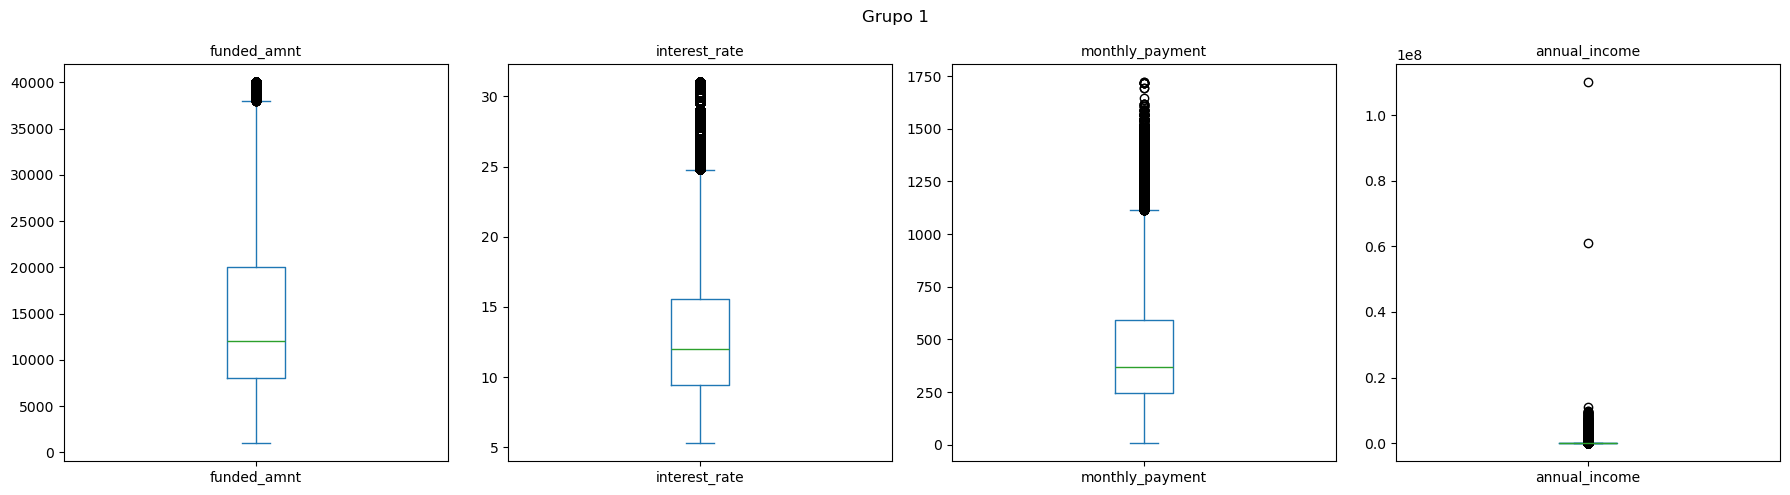

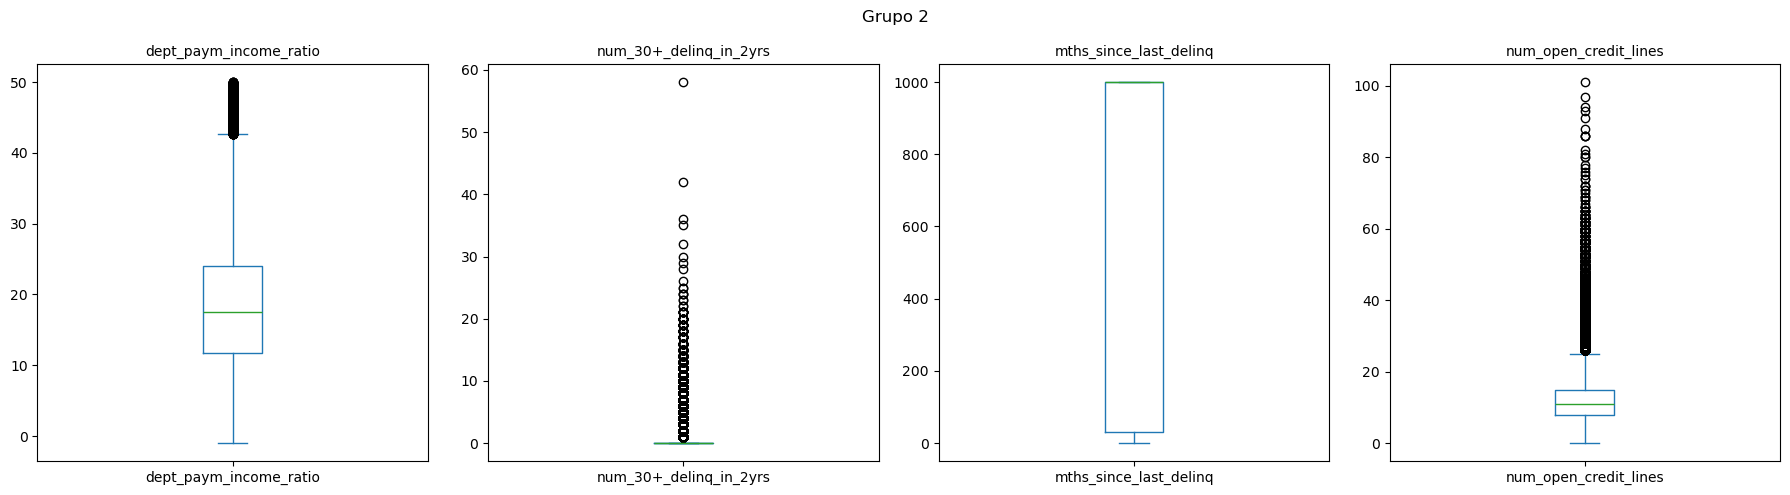

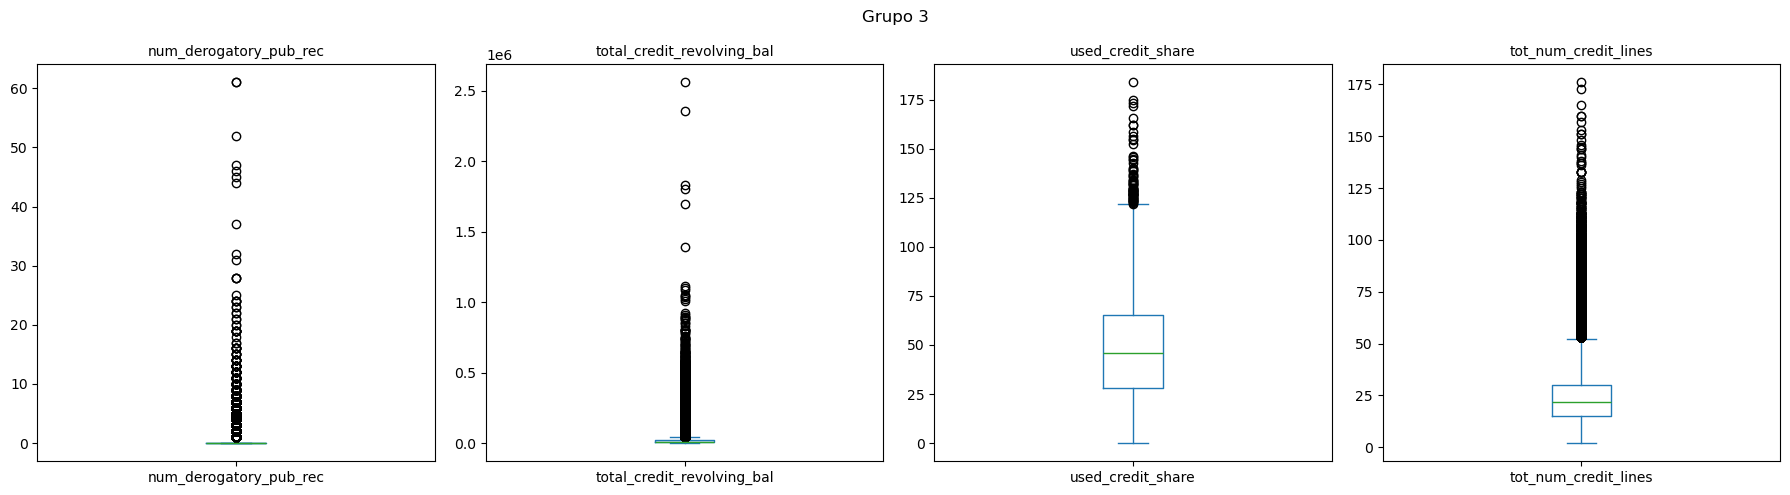

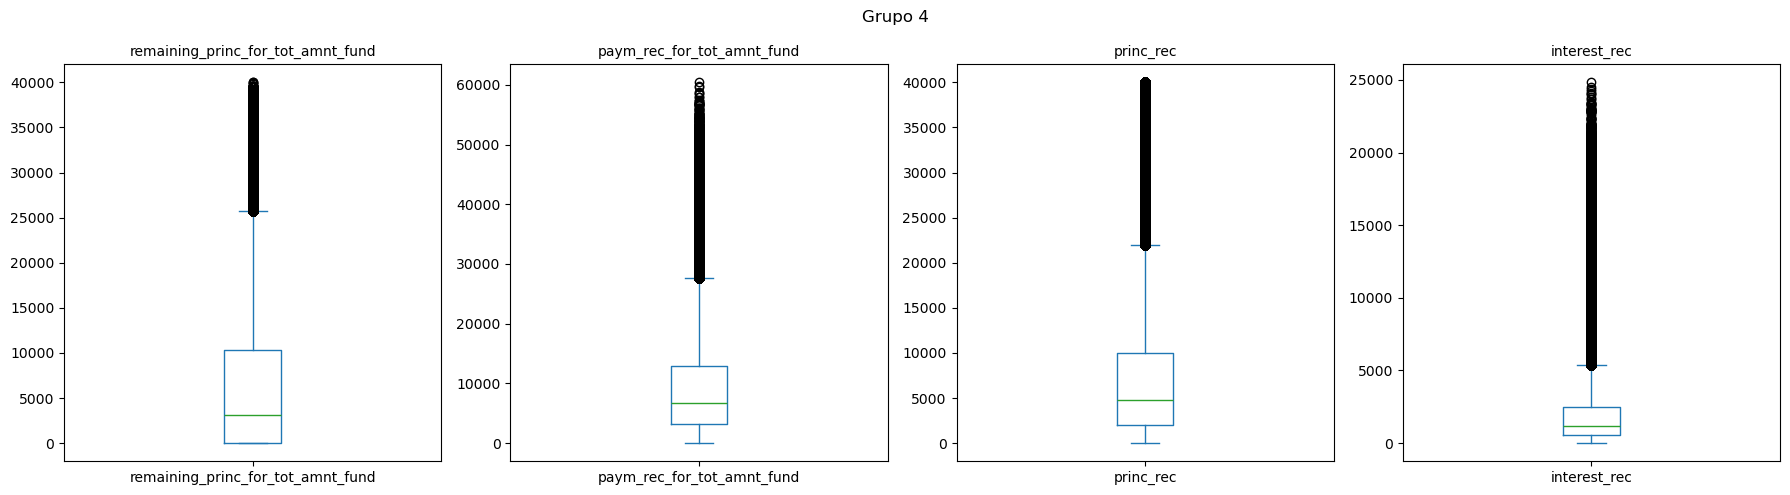

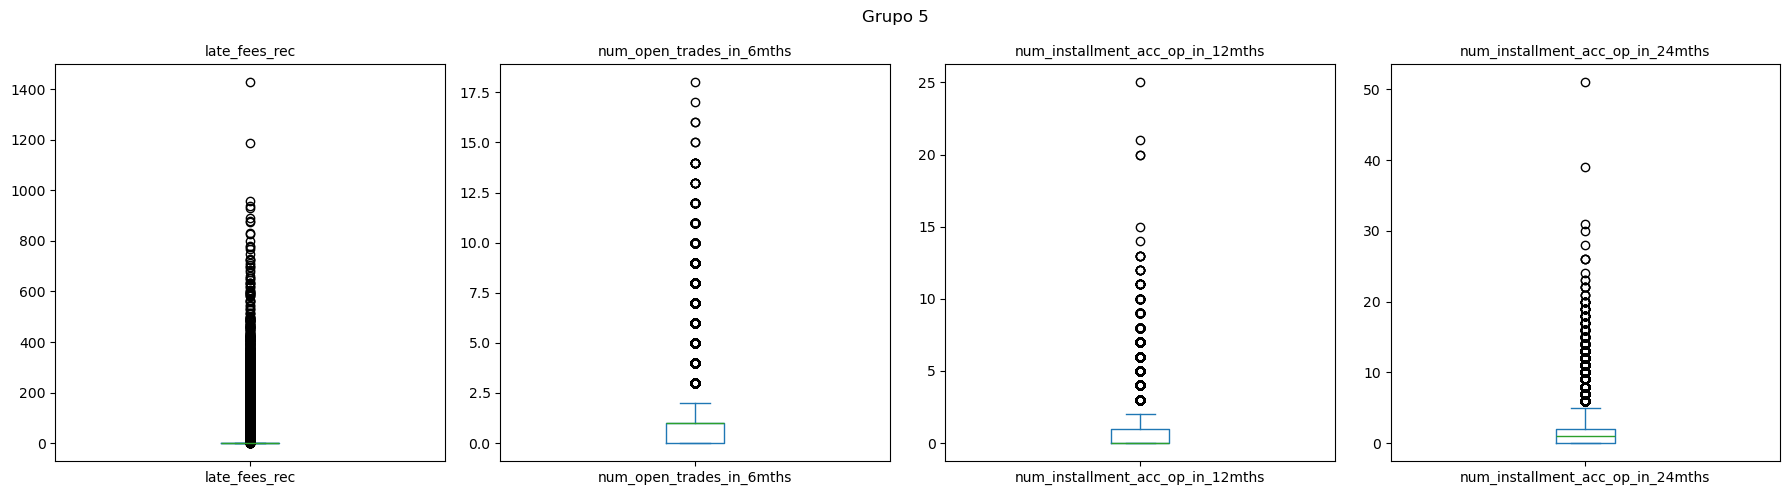

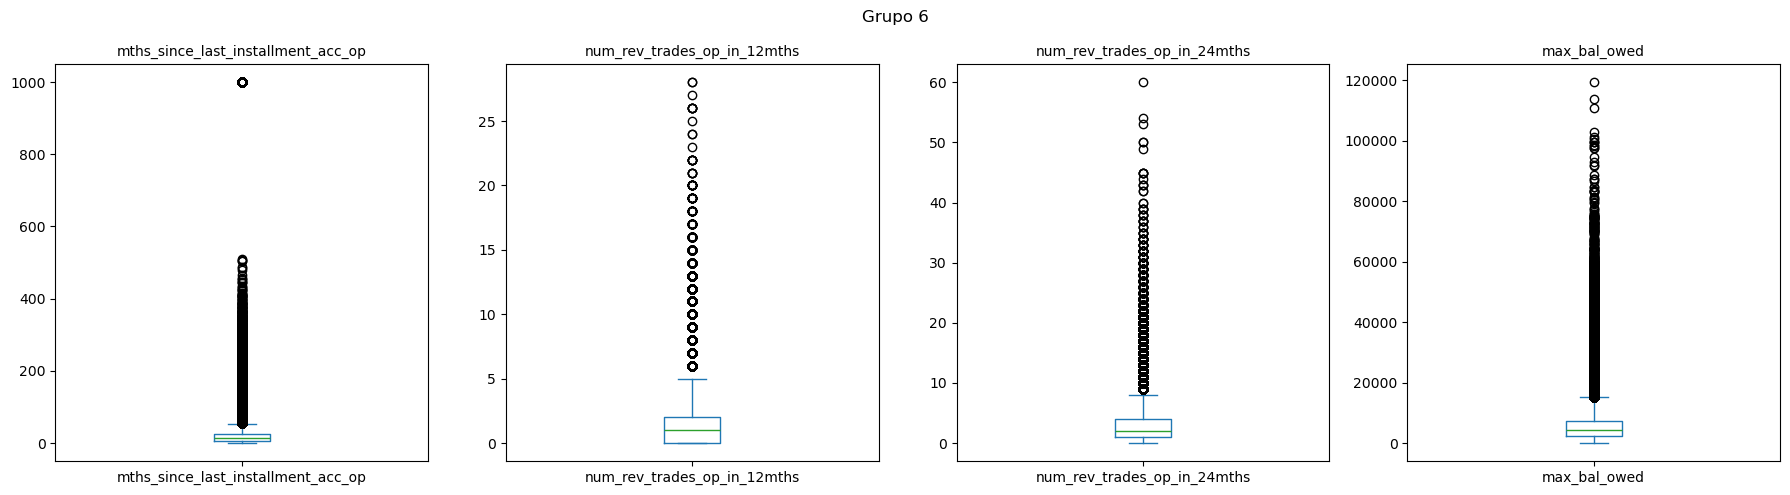

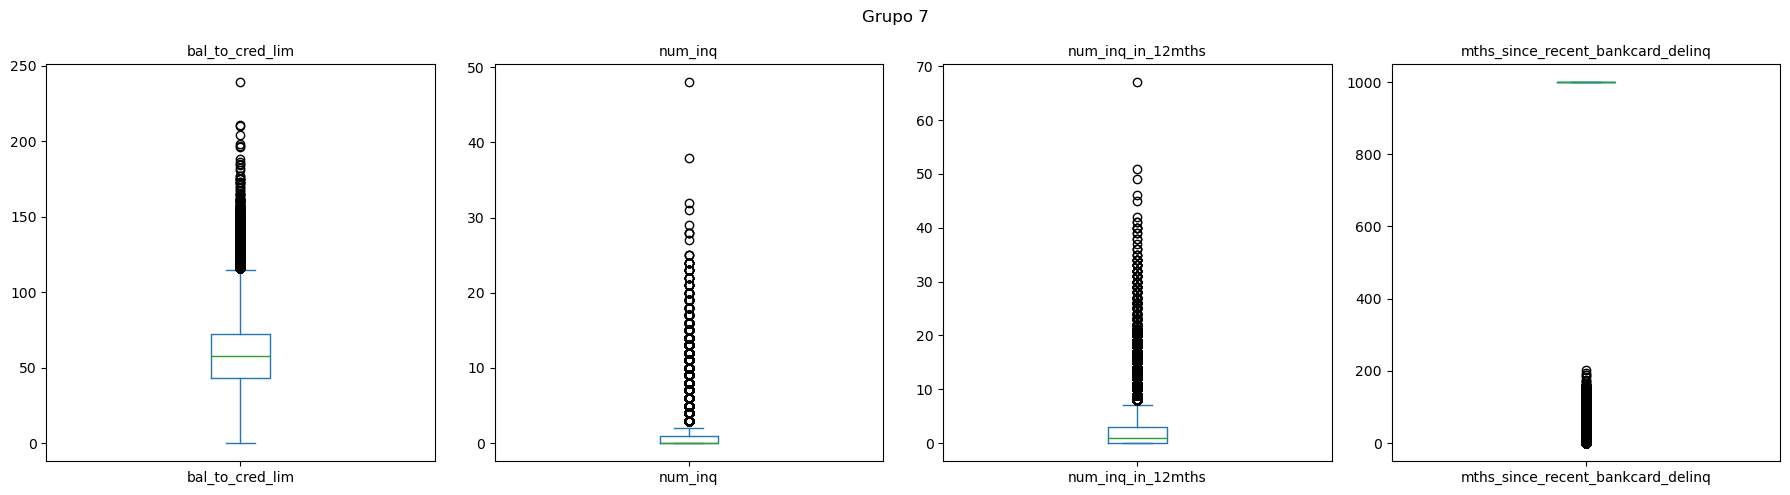

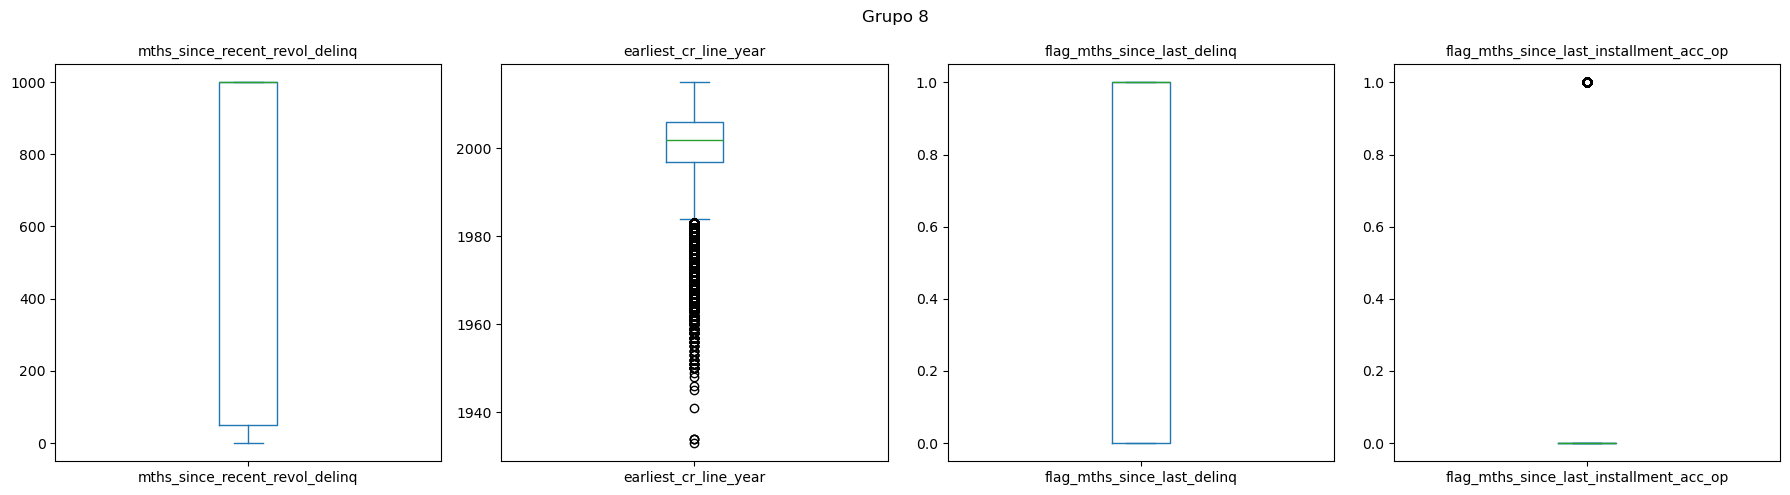

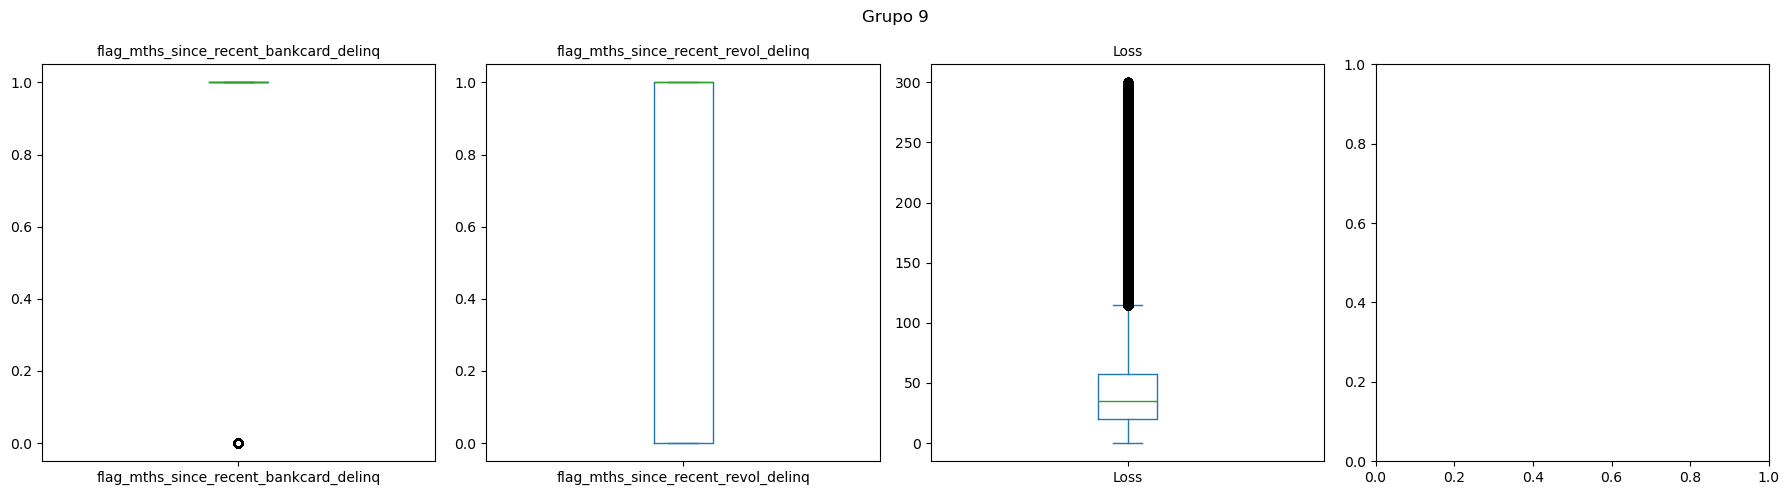

In [119]:
import math
import matplotlib.pyplot as plt

n = 4
grupos = [num_cols[i:i+n] for i in range(0, len(num_cols), n)]

for i, grupo in enumerate(grupos):
   fig, axes = plt.subplots(1, n, figsize=(18, 5))
   for j, col in enumerate(grupo):
       df[col].plot(kind='box', ax=axes[j])
       axes[j].set_title(col, fontsize=10)
       axes[j].set_xlabel('')
   plt.suptitle(f'Grupo {i+1}', fontsize=12)
   plt.tight_layout()
   plt.show()


In [120]:
df['annual_income'].describe()

count    1.257995e+06
mean     8.164390e+04
std      1.394705e+05
min      1.900000e+03
25%      4.800000e+04
50%      6.825000e+04
75%      9.769750e+04
max      1.100000e+08
Name: annual_income, dtype: float64

In [121]:
# We use the 0.99 quantile for high incomes
p99 = df['annual_income'].quantile(0.99)
df['annual_income'] = df['annual_income'].clip(upper=p99)

In [122]:
df['num_30+_delinq_in_2yrs'].describe()

count    1.257995e+06
mean     3.082715e-01
std      8.817419e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      5.800000e+01
Name: num_30+_delinq_in_2yrs, dtype: float64

num_30+_delinq_in_2yrs → number of times the customer had a payment more than 30 days overdue in the last 2 years. A value of 60 is clearly a data error or an extremely rare case. The typical range is 0–3. 

num_open_credit_lines → number of currently open credit lines (cards, loans, etc.). A value of 100+ is unusual but possible for highly financially active customers.

In [123]:
cols_cap = [
    'num_30+_delinq_in_2yrs',
    'num_open_credit_lines'
]

for col in cols_cap:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

num_derogatory_pub_rec → number of negative public records for the customer (bankruptcies, liens, lawsuits). The typical value is 0. A high value indicates a severely damaged credit history.

total_credit_revolving_bal → total current balance across all revolving credit accounts (credit cards). A value of $2.5M is clearly an extreme outlier.

used_credit_share → percentage of available credit currently being used. Also known as "credit utilization." Mathematically, it cannot exceed 100%, which is why the logical cap is set at 100 rather than the 99th percentile (p99). A high value indicates the customer is using nearly all their available credit → a risk signal.

tot_num_credit_lines → total number of credit lines the customer has held throughout their credit history (both open and closed). Includes credit cards, loans, mortgages, etc.

In [124]:
col_cap3 = [
    'num_derogatory_pub_rec',
    'total_credit_revolving_bal',
    'tot_num_credit_lines'
]

for col in col_cap3:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99) 

#used_credit_share represents a percentage, so it should not exceed 100 

df['used_credit_share'] = df['used_credit_share'].clip(upper=100)

Group 4

remaining_princ_for_tot_amnt_fund → outstanding loan principal. The amount of principal the client still owes, excluding interest.

paym_rec_for_tot_amnt_fund → total payments received to date against the financed amount. Includes both principal and interest payments.

princ_rec → principal capital already recovered. The amount the client has paid specifically toward the original loan amount, excluding interest.

interest_rec → interest already collected from the client to date.

These variables are crucial for the LGD model (Phase 3), as they describe how much of the loan has been recovered. If a client defaults but has already paid off 80% of the principal, the actual loss is significantly lower. However, care must be taken regarding data leakage; these variables reflect the loan's current status and could be directly correlated with the target variable, which would artificially inflate the model's performance.

In [125]:
correlaciones = df[['remaining_princ_for_tot_amnt_fund', 
                     'paym_rec_for_tot_amnt_fund',
                     'princ_rec', 
                     'interest_rec']].corrwith(y['y'])

print(correlaciones.sort_values(ascending=False))

interest_rec                         0.047986
paym_rec_for_tot_amnt_fund          -0.102025
princ_rec                           -0.165658
remaining_princ_for_tot_amnt_fund   -0.191035
dtype: float64


The correlations are very low; none exceed 0.20 in absolute value. This means there is no risk of significant leakage, so we can keep them in the model.

|Variable                           |Correlation|Interpretation|
|-----------------------------------|-----------|--------------|
|`interest_rec`                     |0.05       |Negligible    |
|`paym_rec_for_tot_amnt_fund`       |-0.10      |Very low      |
|`princ_rec`                        |-0.17      |Low           |
|`remaining_princ_for_tot_amnt_fund`|-0.19      |Low           |

The negative correlation makes sense: the more principal recovered, the lower the probability of default, because good payers are the ones who have paid the most.

Decision: we keep them all.

late_fees_rec → late payment fees charged to the customer. Outliers up to 1,400. ⚠️ Capped at the 99th percentile.

•num_open_trades_in_6mths → number of new accounts opened in the last 6 months. Moderate outliers. ⚠️ Capped at the 99th percentile.
•num_installment_acc_op_in_12mths → installment-type accounts opened in the last 12 months. Minor outliers. ⚠️ Capped at the 99th percentile.
•num_installment_acc_op_in_24mths → installment-type accounts opened in the last 24 months. Minor outliers. ⚠️ Capped at the 99th percentile.

•mths_since_last_installment_acc_op → months since the last installment account was opened. A value of 1,000 represents the imputed 999. ✅ Do not modify.
•num_rev_trades_op_in_12mths → revolving accounts opened in the last 12 months. High outliers. ⚠️ Capped at the 99th percentile.
•num_rev_trades_op_in_24mths → revolving accounts opened in the last 24 months. High outliers. ⚠️ Capped at the 99th percentile.
•max_bal_owed → maximum outstanding balance. Outliers up to 120,000. ⚠️ Capped at the 99th percentile.

In [126]:
cols_cap5y6 = [
    'late_fees_rec',
    'num_open_trades_in_6mths',
    'num_installment_acc_op_in_12mths',
    'num_installment_acc_op_in_24mths',
    'num_rev_trades_op_in_12mths',
    'num_rev_trades_op_in_24mths',
    'max_bal_owed'
]

for col in cols_cap5y6:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

•bal_to_cred_lim → percentage of credit limit being used. Outliers up to 250 (logical maximum is 100%). ⚠️ Capped at 100.
•num_inq → total number of credit bureau inquiries. Outliers up to 50. ⚠️ Capped at the 99th percentile.
•num_inq_in_12mths → bureau inquiries in the last 6 months. Moderate outliers. ⚠️ Capped at the 99th percentile.
•mths_since_recent_bankcard_delinq → values ​​of 1000 represent imputed 999s. ✅ Do not modify.

•mths_since_recent_revol_delinq → values ​​of 1000 represent imputed 999s. ✅ Do not modify.
•earliest_cr_line_year → year the first credit line was opened. Range 1940–2010; no outliers. ✅ Do not modify.
•flag_mths_since_last_delinq → binary flag (0/1). ✅ Do not modify.
•flag_mths_since_last_installment_acc_op → binary flag (0/1) with a visible outlier → review.

In [127]:
# Logical cap in 100 (it is a percentage)
df['bal_to_cred_lim'] = df['bal_to_cred_lim'].clip(upper=100)

# Cap on p99
cols_cap7 = ['num_inq', 'num_inq_in_12mths']

for col in cols_cap7:
    p99 = df[col].quantile(0.99)
    df[col] = df[col].clip(upper=p99)

In [128]:
print(df['earliest_cr_line_year'].value_counts().sort_index().head(10))

earliest_cr_line_year
1933     1
1934     3
1941     1
1945     1
1946     1
1948     1
1949     1
1950    11
1951     9
1952     6
Name: count, dtype: int64


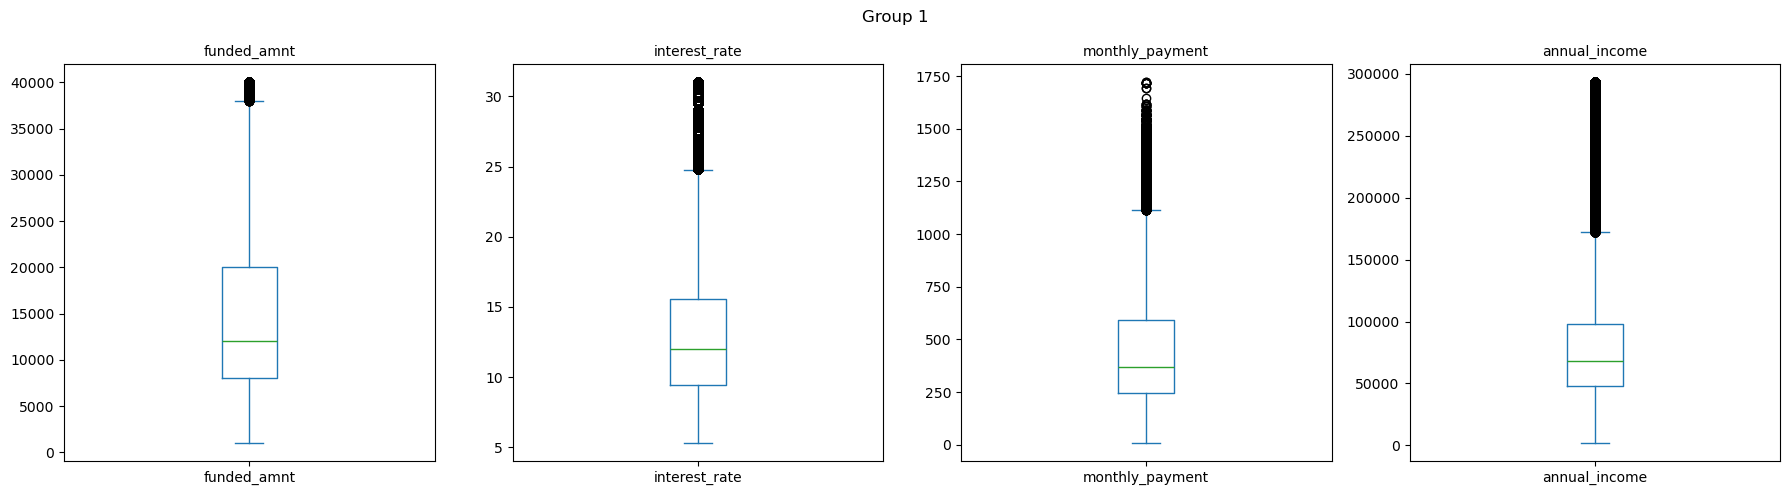

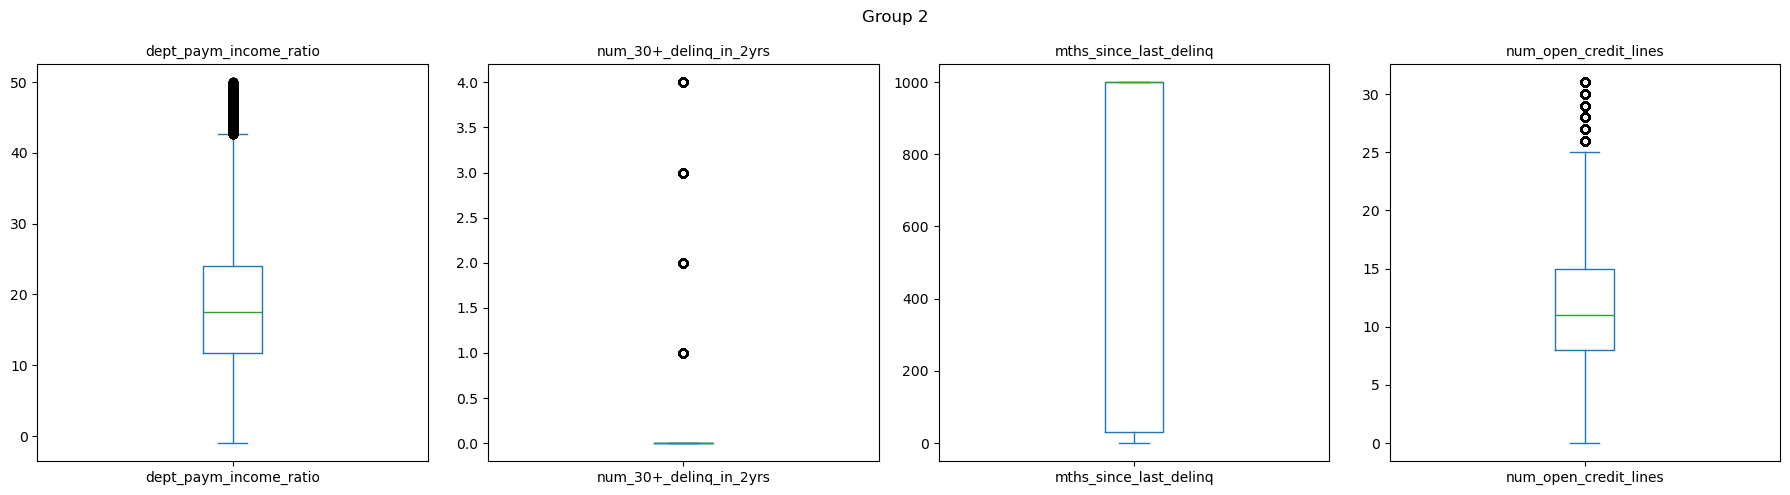

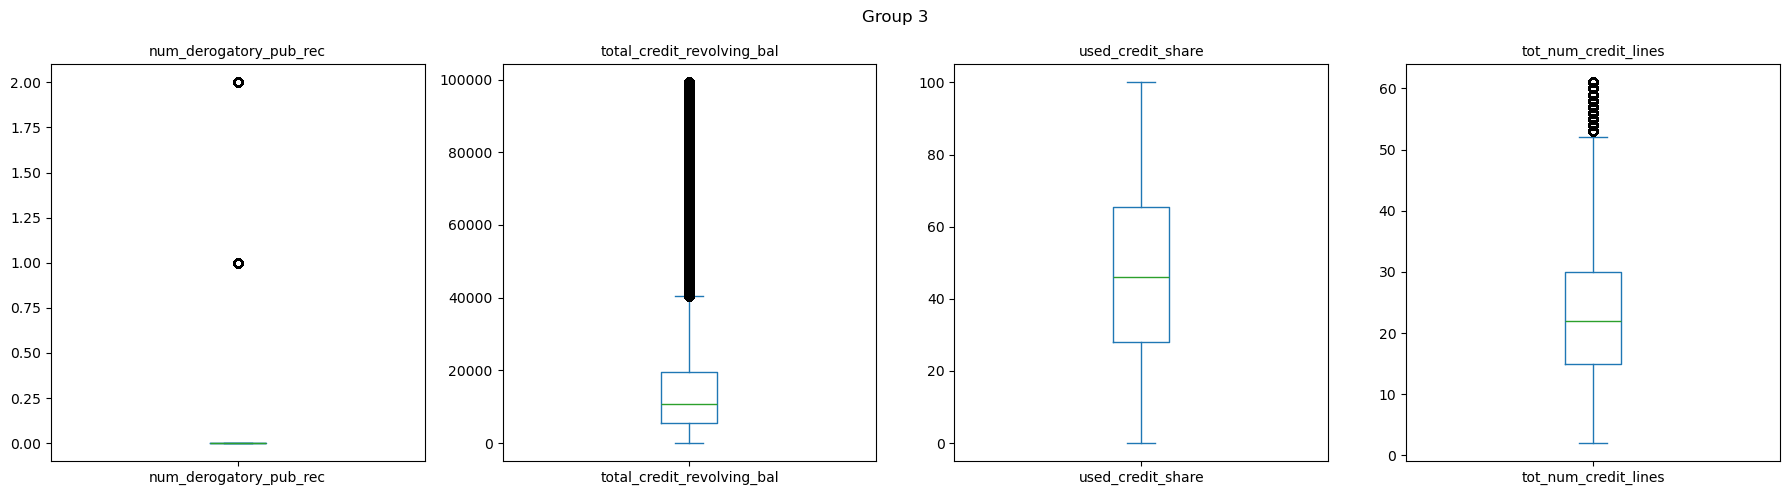

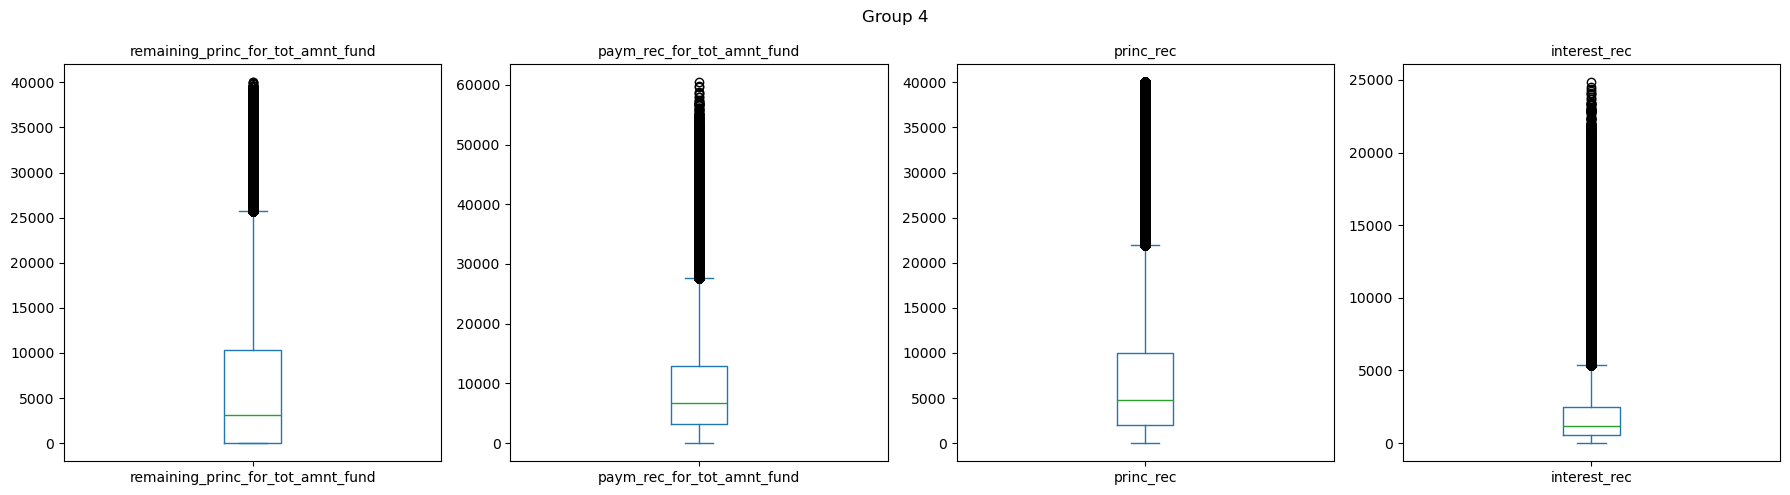

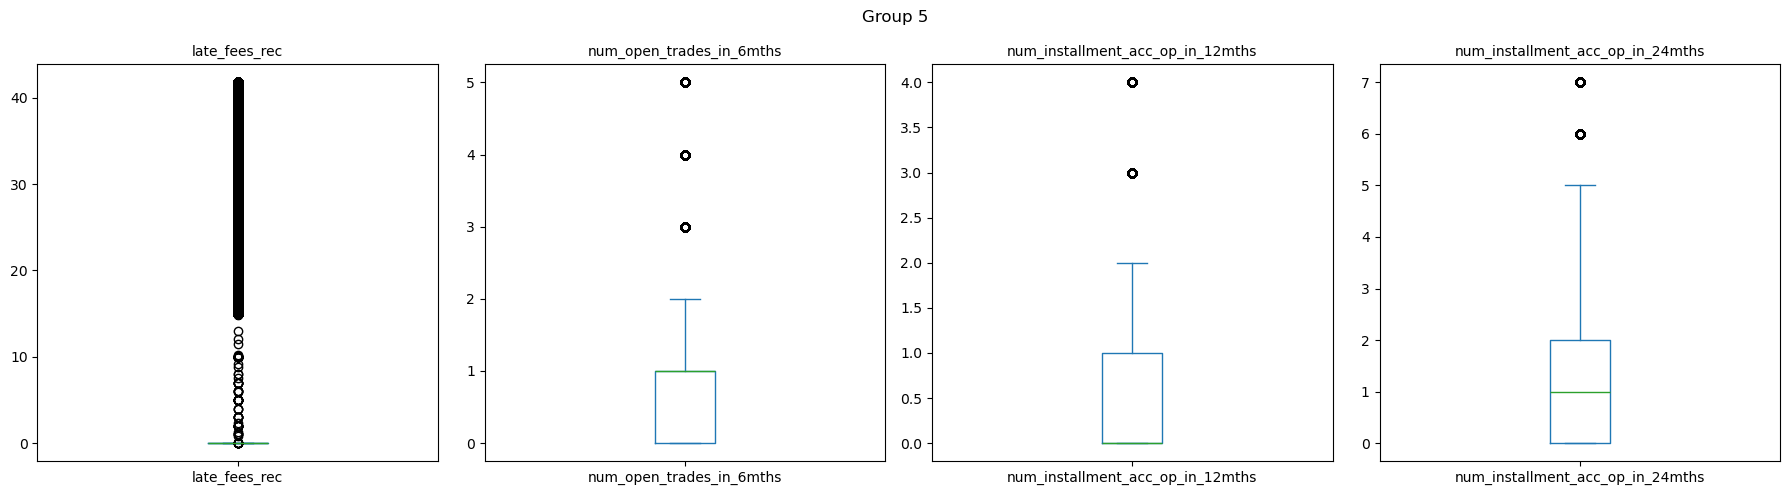

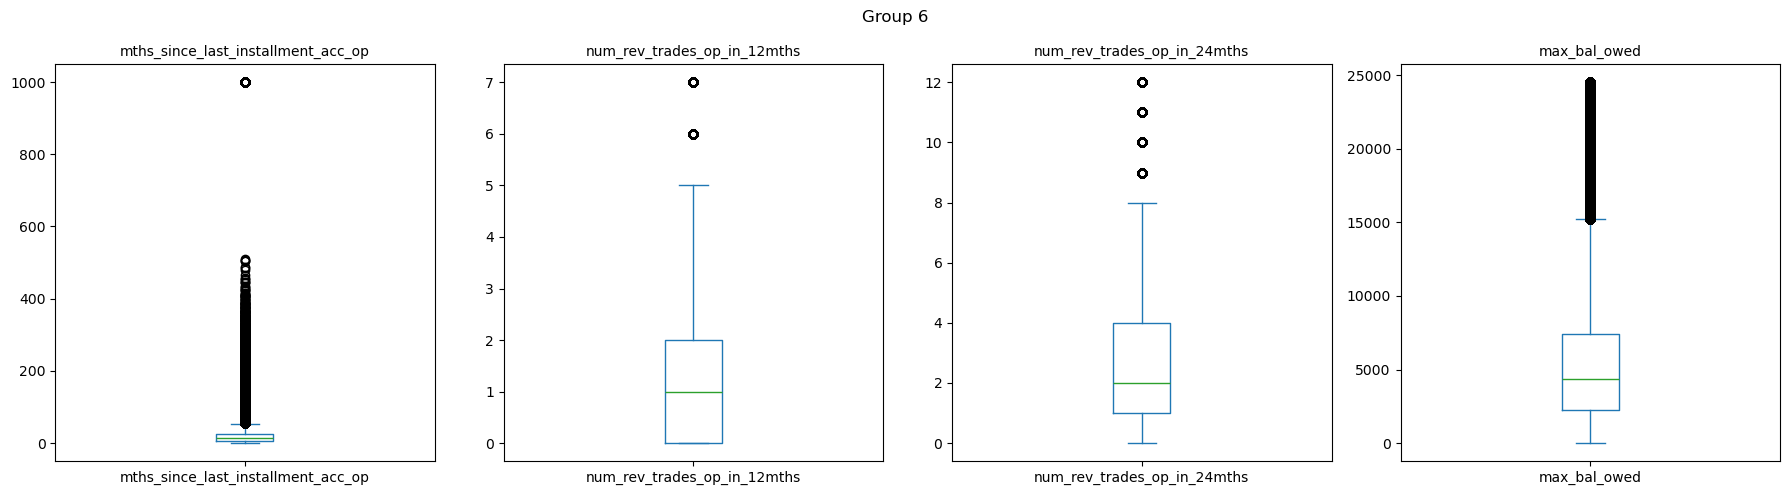

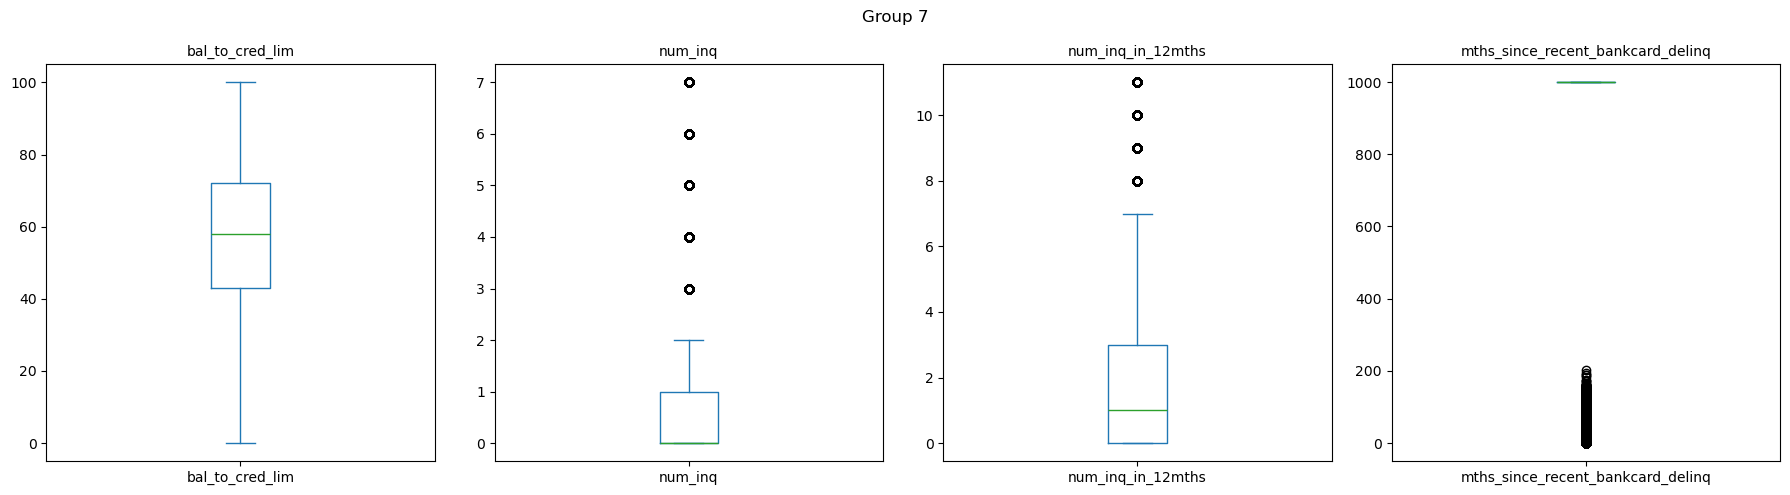

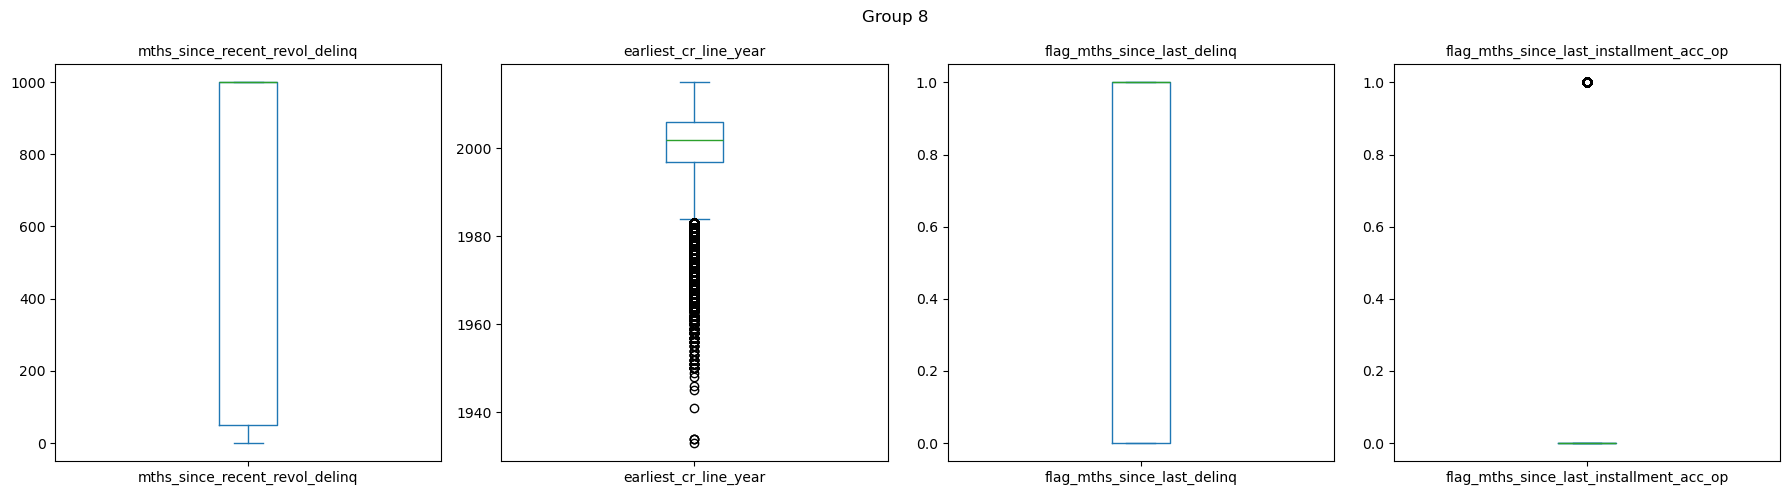

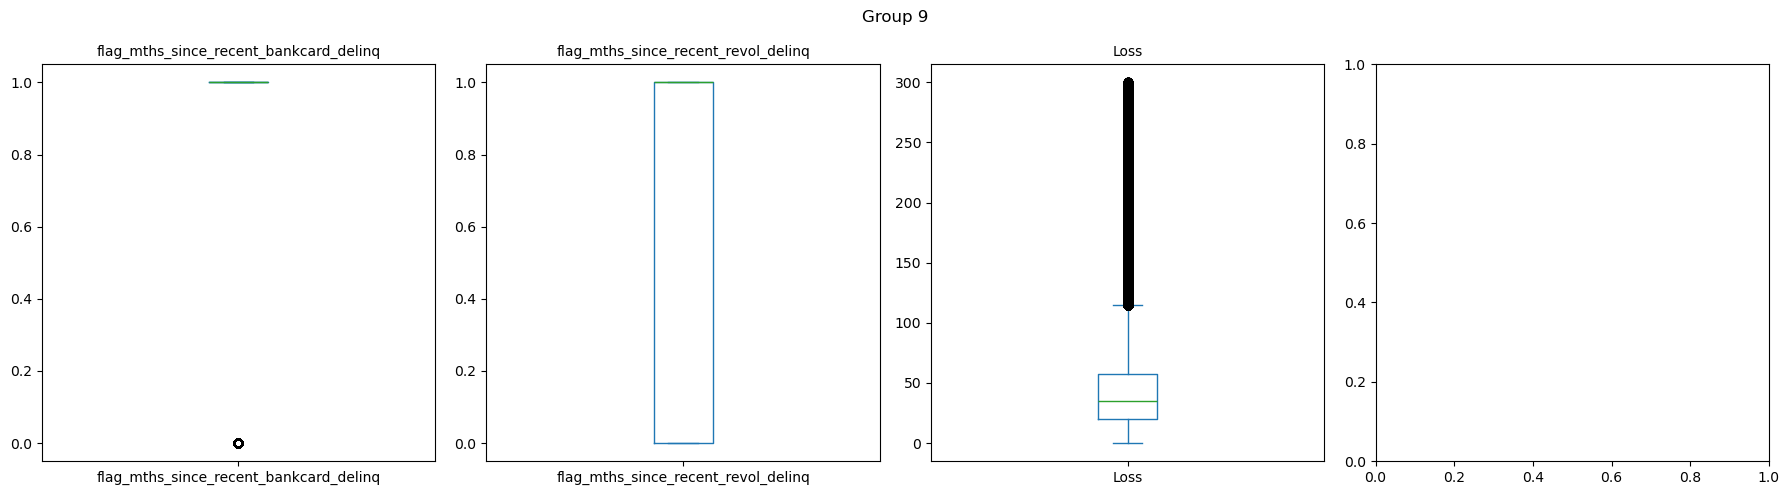

In [129]:
import math
import matplotlib.pyplot as plt

n = 4
groups = [num_cols[i:i+n] for i in range(0, len(num_cols), n)]

for i, group in enumerate(groups):
   fig, axes = plt.subplots(1, n, figsize=(18, 5))
   for j, col in enumerate(group):
       df[col].plot(kind='box', ax=axes[j])
       axes[j].set_title(col, fontsize=10)
       axes[j].set_xlabel('')
   plt.suptitle(f'Group {i+1}', fontsize=12)
   plt.tight_layout()
   plt.show()

## Processing categorical columns

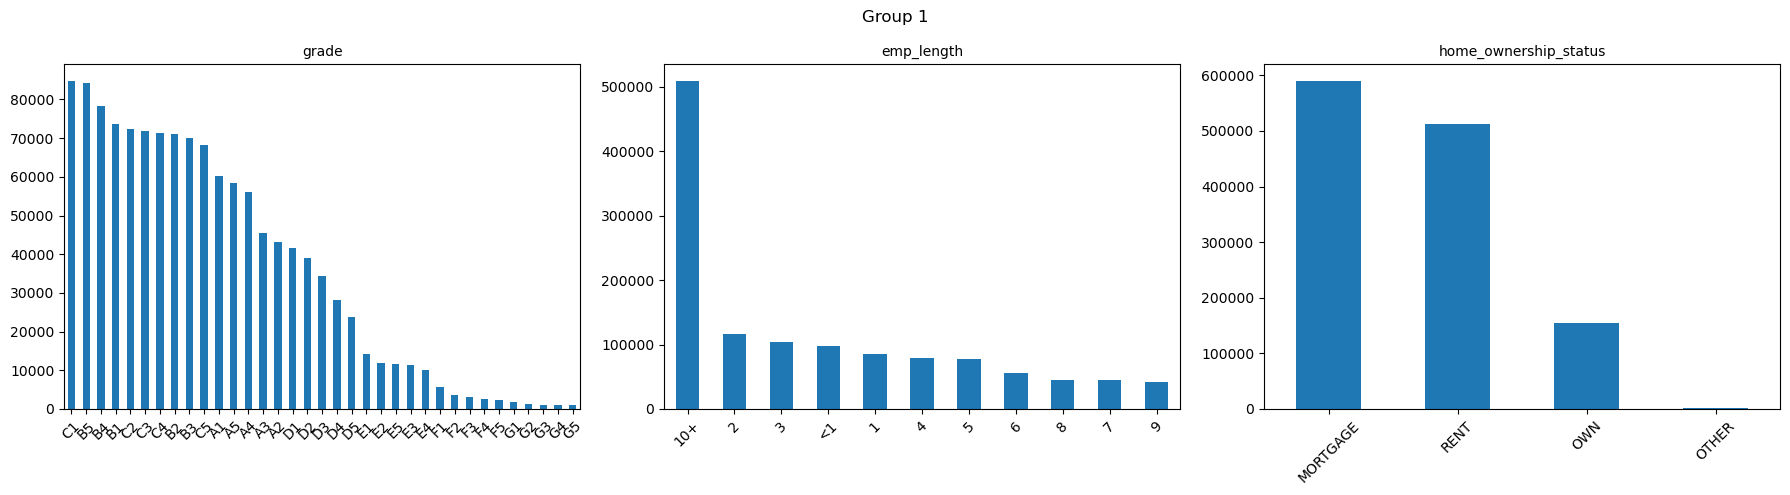

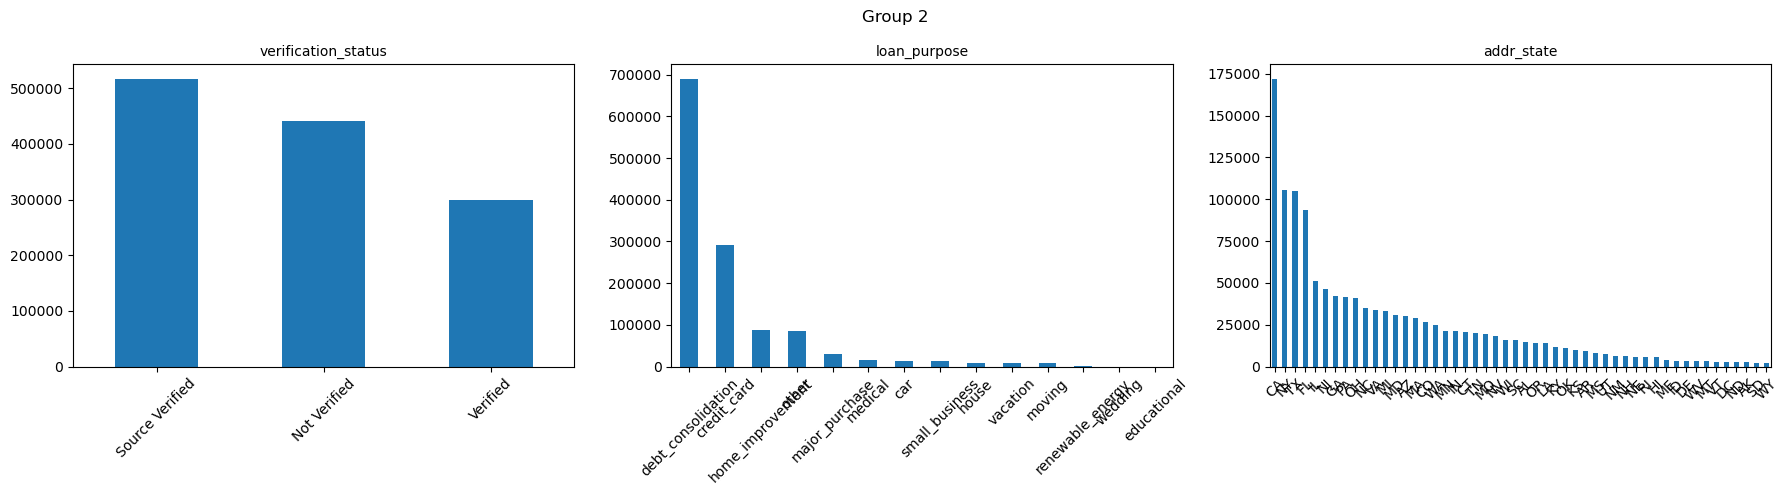

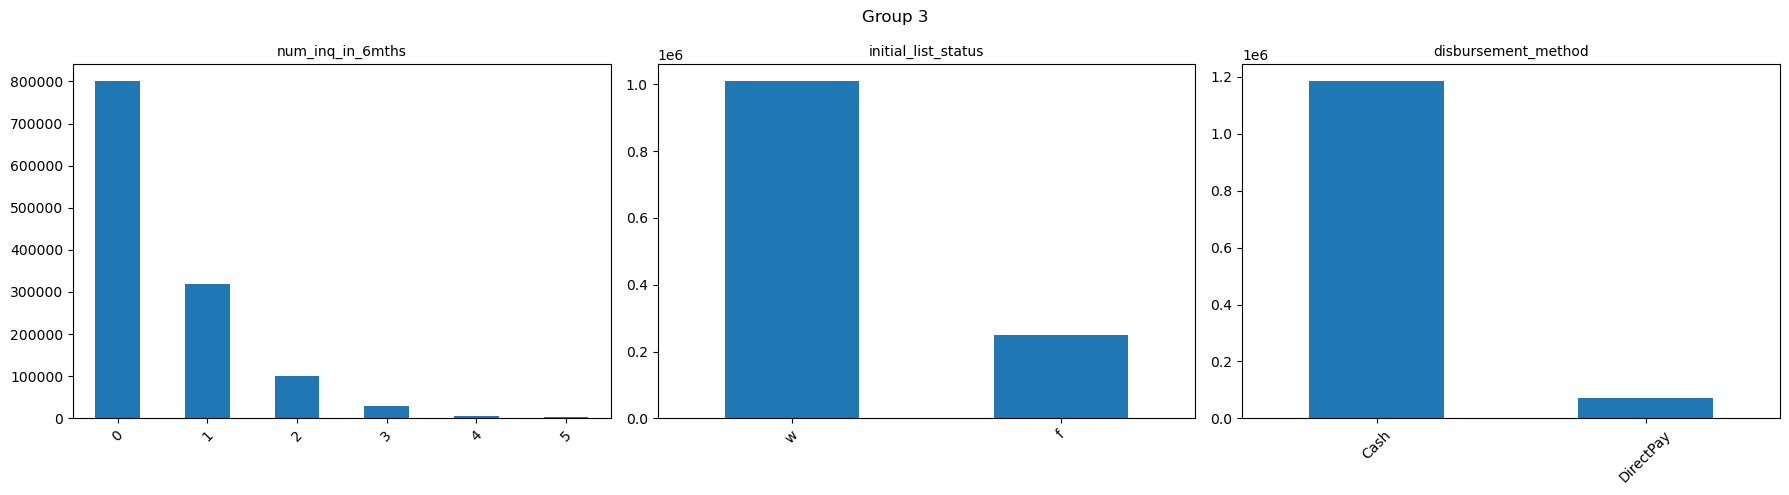

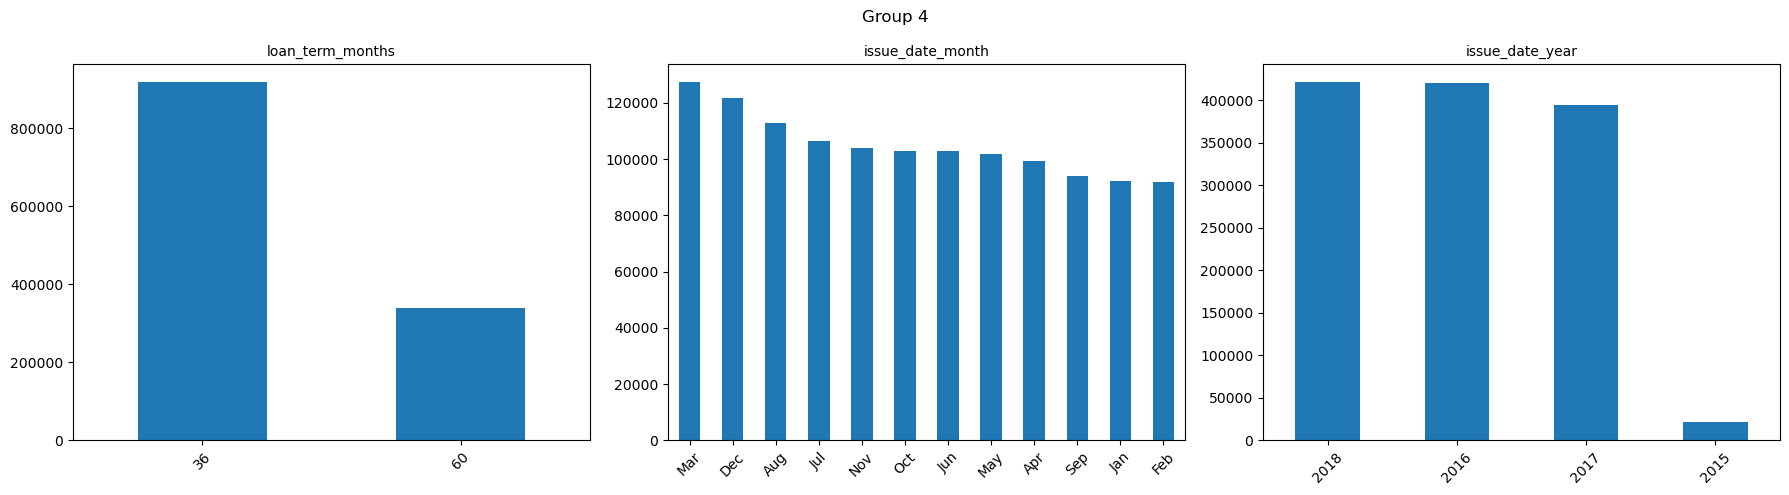

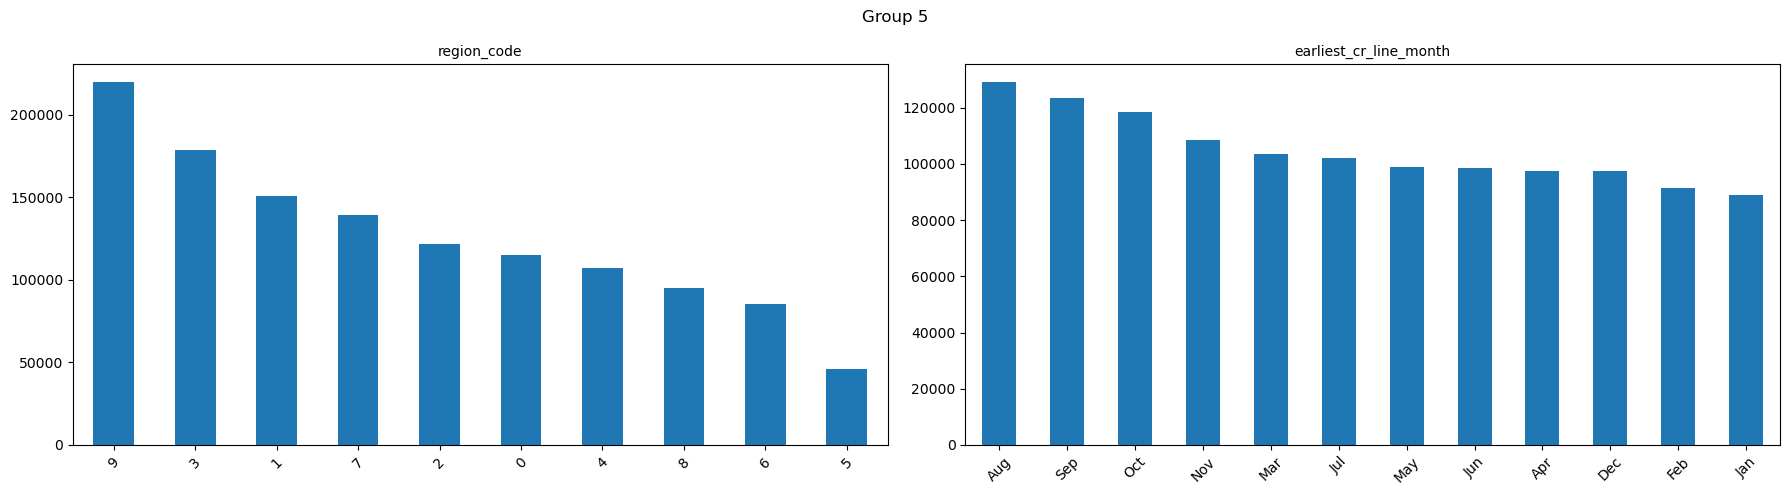

In [130]:
import math
import matplotlib.pyplot as plt

n = 3
groups = [cat_cols[i:i+n] for i in range(0, len(cat_cols), n)]

for i, group in enumerate(groups):
   fig, axes = plt.subplots(1, len(group), figsize=(18, 5))
   if len(group) == 1:
       axes = [axes]
   for j, col in enumerate(group):
       df[col].value_counts().plot(kind='bar', ax=axes[j], rot=45)
       axes[j].set_title(col, fontsize=10)
       axes[j].set_xlabel('')
   plt.suptitle(f'Group {i+1}', fontsize=12)
   plt.tight_layout()
   plt.show()

In [131]:
grade_map = {
   'A1': 'A', 'A2': 'A', 'A3': 'A', 'A4': 'A', 'A5': 'A',
   'B1': 'B', 'B2': 'B', 'B3': 'B', 'B4': 'B', 'B5': 'B',
   'C1': 'C', 'C2': 'C', 'C3': 'C', 'C4': 'C', 'C5': 'C',
   'D1': 'D', 'D2': 'D', 'D3': 'D', 'D4': 'D', 'D5': 'D',
   'E1': 'E', 'E2': 'E', 'E3': 'E', 'E4': 'E', 'E5': 'E',
   'F1': 'F', 'F2': 'F', 'F3': 'F', 'F4': 'F', 'F5': 'F',
   'G1': 'G', 'G2': 'G', 'G3': 'G', 'G4': 'G', 'G5': 'G'
}

df['grade'] = df['grade'].map(grade_map)

In [132]:
purpose_map = {
    'debt_consolidation': 'debt_consolidation',
    'credit_card': 'credit_card',
    'home_improvement': 'home_improvement',
    'major_purchase': 'major_purchase',
    'car': 'car',
    'small_business': 'small_business',
    'vacation': 'vacation',
    'moving': 'moving',
    'renewable_energy': 'other',
    'educational': 'other',
    'medical': 'other',
    'house': 'other',
    'wedding': 'other',
    'other': 'other'
}
df['loan_purpose'] = df['loan_purpose'].map(purpose_map)

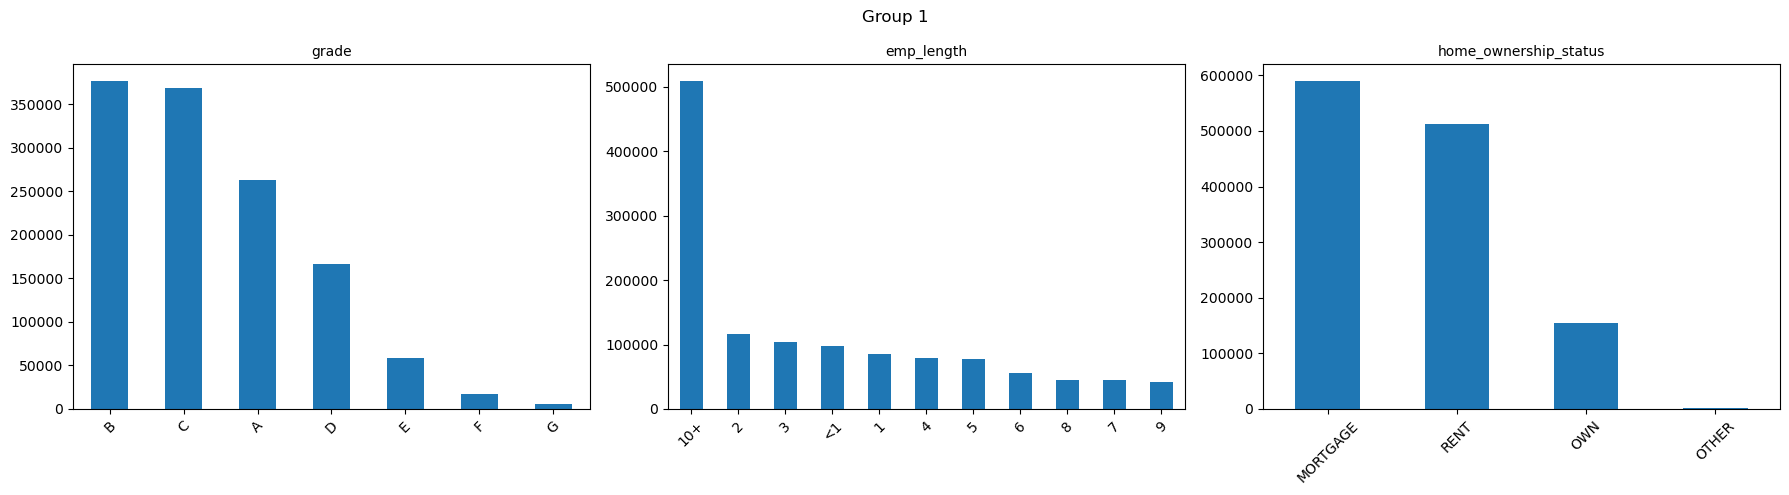

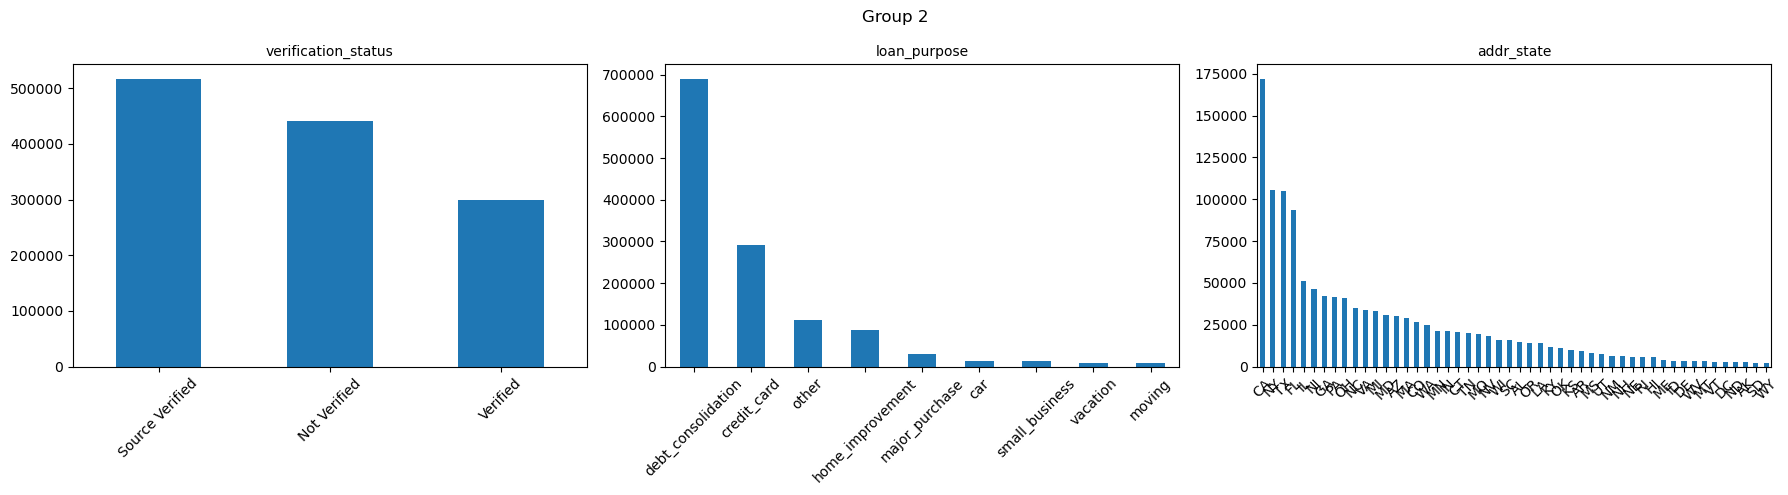

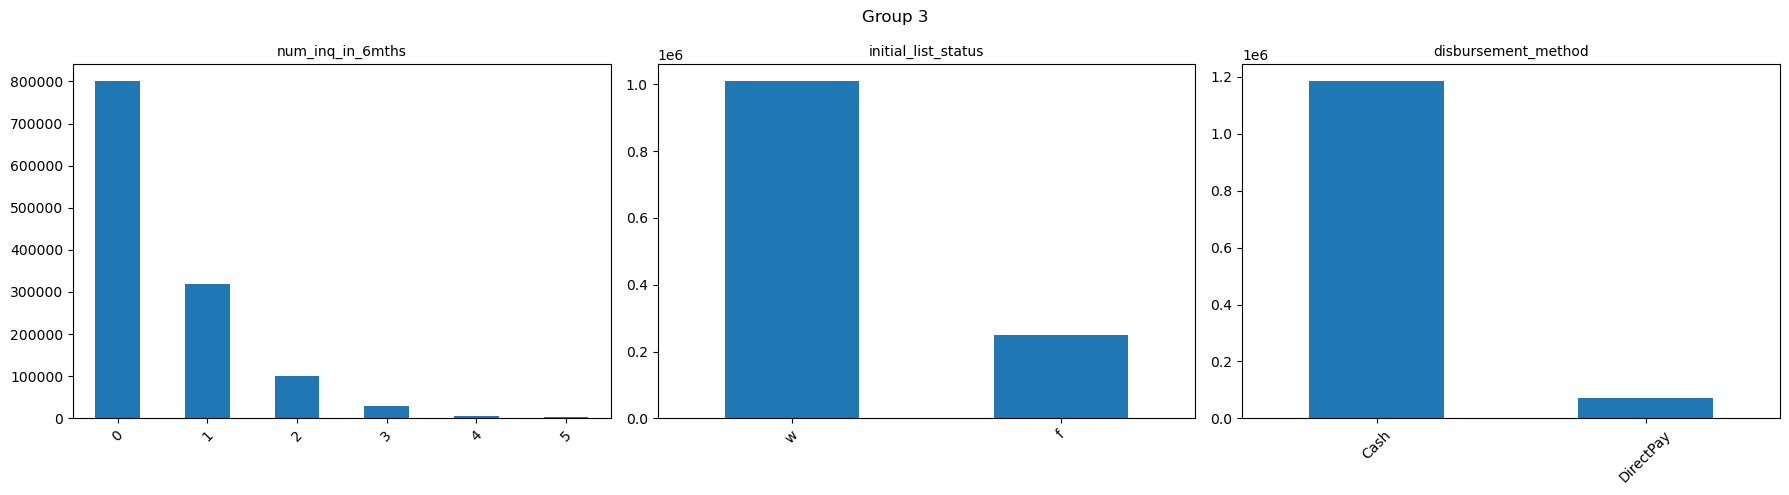

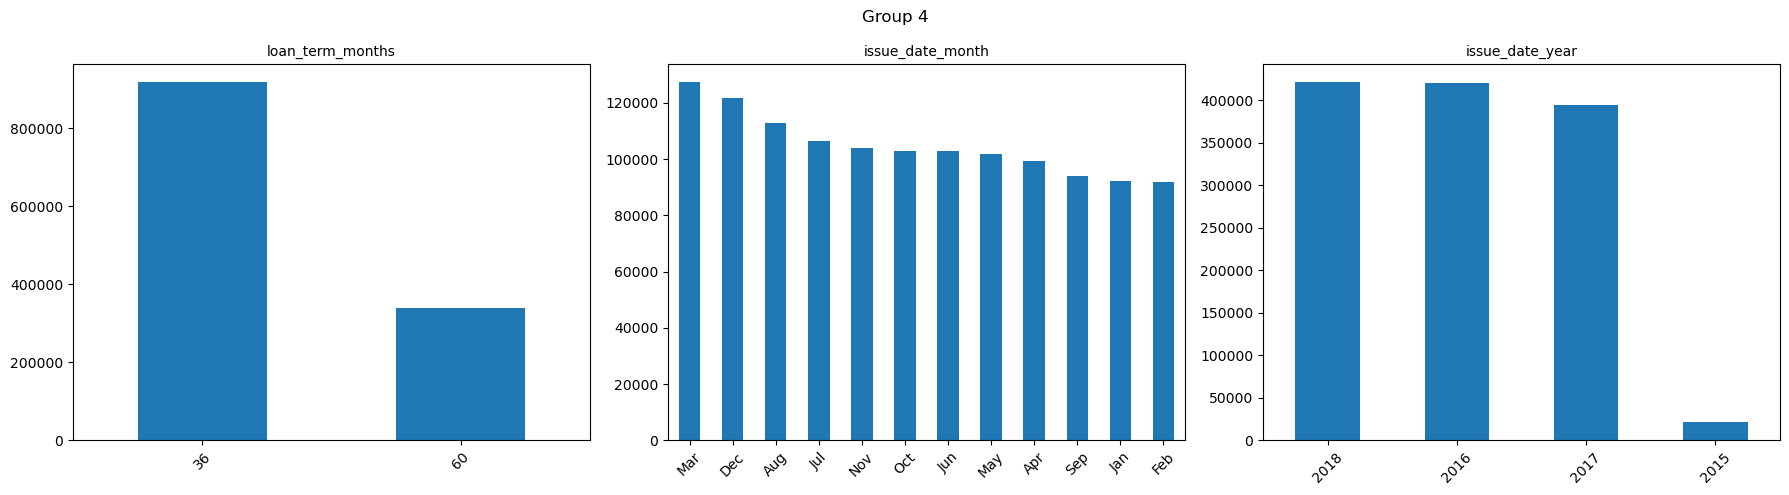

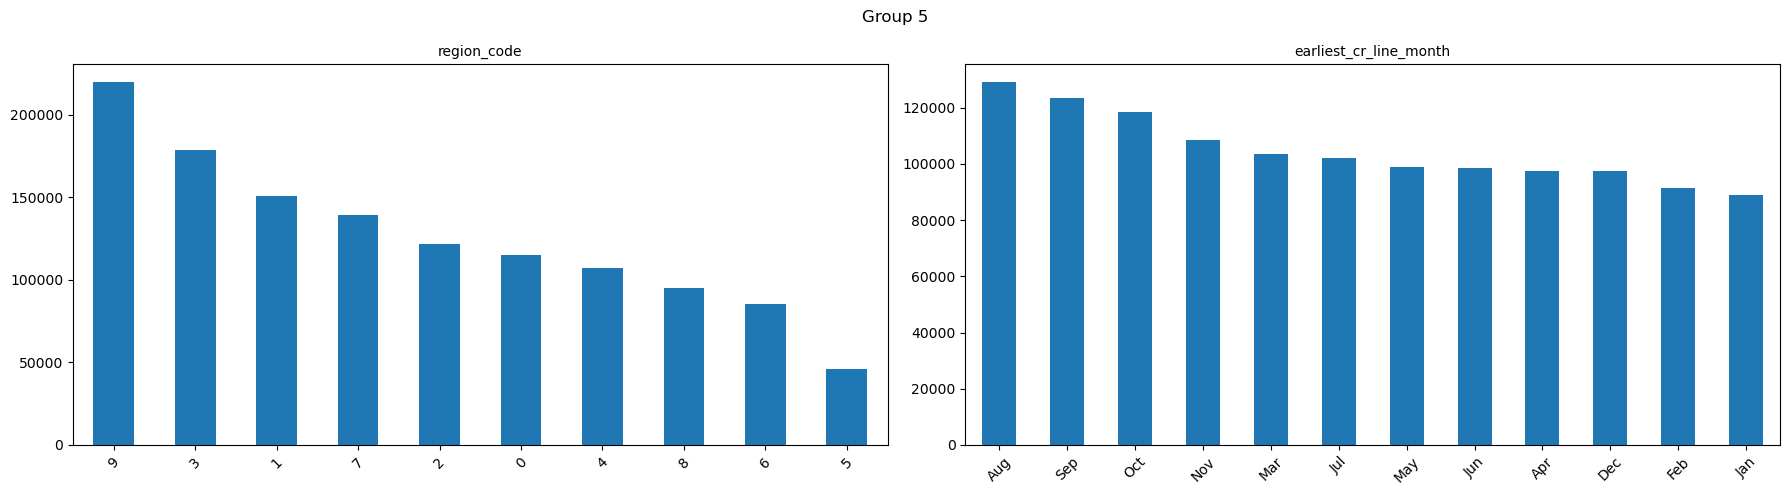

In [133]:
import math
import matplotlib.pyplot as plt

n = 3
groups = [cat_cols[i:i+n] for i in range(0, len(cat_cols), n)]

for i, group in enumerate(groups):
   fig, axes = plt.subplots(1, len(group), figsize=(18, 5))
   if len(group) == 1:
       axes = [axes]
   for j, col in enumerate(group):
       df[col].value_counts().plot(kind='bar', ax=axes[j], rot=45)
       axes[j].set_title(col, fontsize=10)
       axes[j].set_xlabel('')
   plt.suptitle(f'Group {i+1}', fontsize=12)
   plt.tight_layout()
   plt.show()

In [134]:
#as we have region code, we proceed to eliminate addr_state 
df.drop(['addr_state'], axis=1, inplace=True)

Because machine learning models do not understand text, only numbers.

	•	Jan, Feb → the model does not know that Feb comes after Jan
	•	2015, 2016 → if they are strings, the model treats them as unordered categories

By converting them to numbers:

	•	The model understands that 12 (Dec) > 1 (Jan)
	•	It understands that 2018 > 2015
	•	They can be used directly without needing OHE, saving columns

•	Converting to numeric → the model treats it as an ordinal variable (2018 > 2017 > 2016 > 2015), which makes sense since more recent years may reflect different market conditions

In [135]:
# issue_date_month y earliest_cr_line_month → numeric
month_map = {
    'Jan':1, 'Feb':2, 'Mar':3, 'Apr':4, 'May':5, 'Jun':6,
    'Jul':7, 'Aug':8, 'Sep':9, 'Oct':10, 'Nov':11, 'Dec':12
}

df['issue_date_month'] = df['issue_date_month'].map(month_map)
df['earliest_cr_line_month'] = df['earliest_cr_line_month'].map(month_map)

# issue_date_year → numeric
df['issue_date_year'] = df['issue_date_year'].astype(int)


In [136]:
df.select_dtypes(include='object').columns

Index(['grade', 'emp_length', 'home_ownership_status', 'verification_status',
       'loan_purpose', 'num_inq_in_6mths', 'initial_list_status',
       'disbursement_method', 'loan_term_months', 'region_code'],
      dtype='str')

In [137]:
# Select numeric columns from the dataframe 
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numerical: ", num_cols)

# Select categorical columns from the dataframe 
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print("Categorical: ", cat_cols)

Numerical:  ['funded_amnt', 'interest_rate', 'monthly_payment', 'annual_income', 'dept_paym_income_ratio', 'num_30+_delinq_in_2yrs', 'mths_since_last_delinq', 'num_open_credit_lines', 'num_derogatory_pub_rec', 'total_credit_revolving_bal', 'used_credit_share', 'tot_num_credit_lines', 'remaining_princ_for_tot_amnt_fund', 'paym_rec_for_tot_amnt_fund', 'princ_rec', 'interest_rec', 'late_fees_rec', 'num_open_trades_in_6mths', 'num_installment_acc_op_in_12mths', 'num_installment_acc_op_in_24mths', 'mths_since_last_installment_acc_op', 'num_rev_trades_op_in_12mths', 'num_rev_trades_op_in_24mths', 'max_bal_owed', 'bal_to_cred_lim', 'num_inq', 'num_inq_in_12mths', 'mths_since_recent_bankcard_delinq', 'mths_since_recent_revol_delinq', 'issue_date_month', 'issue_date_year', 'earliest_cr_line_month', 'earliest_cr_line_year', 'flag_mths_since_last_delinq', 'flag_mths_since_last_installment_acc_op', 'flag_mths_since_recent_bankcard_delinq', 'flag_mths_since_recent_revol_delinq', 'Loss']
Categorical

In [138]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
df = pd.get_dummies(df, columns=cat_cols, drop_first=False, dtype=int)

In [139]:
df.select_dtypes(include='object').columns

Index([], dtype='str')

In [140]:
# Alinear y con el índice de df
y_pd = y['y'].loc[df.index]

# Verificar que coincidan
print(f'df: {df.shape[0]}')
print(f'y:  {y_pd.shape[0]}')

df: 1257995
y:  1257995


In [141]:
X = df.drop(columns=['Loss'])
y_pd = y['y'].loc[df.index].reset_index(drop=True)
X = X.reset_index(drop=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_pd,
    test_size=0.20,
    random_state=42,
    stratify=y_pd
)

print(f'Train: {X_train.shape}')
print(f'Test:  {X_test.shape}')
print(f'% Defaults Train: {100*y_train.mean():.2f}%')
print(f'% Defaults Test:  {100*y_test.mean():.2f}%')

Train: (1006396, 93)
Test:  (251599, 93)
% Defaults Train: 10.17%
% Defaults Test:  10.17%


In [142]:
#Now we apply the StandardScaler:

from sklearn.preprocessing import StandardScaler
import numpy as np

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [143]:
X_train.head()

,funded_amnt,interest_rate,monthly_payment,annual_income,dept_paym_income_ratio,num_30+_delinq_in_2yrs,mths_since_last_delinq,num_open_credit_lines,num_derogatory_pub_rec,total_credit_revolving_bal,used_credit_share,tot_num_credit_lines,remaining_princ_for_tot_amnt_fund,paym_rec_for_tot_amnt_fund,princ_rec,interest_rec,late_fees_rec,num_open_trades_in_6mths,num_installment_acc_op_in_12mths,num_installment_acc_op_in_24mths,mths_since_last_installment_acc_op,num_rev_trades_op_in_12mths,num_rev_trades_op_in_24mths,max_bal_owed,bal_to_cred_lim,num_inq,num_inq_in_12mths,mths_since_recent_bankcard_delinq,mths_since_recent_revol_delinq,issue_date_month,issue_date_year,earliest_cr_line_month,earliest_cr_line_year,flag_mths_since_last_delinq,flag_mths_since_last_installment_acc_op,flag_mths_since_recent_bankcard_delinq,flag_mths_since_recent_revol_delinq,grade_A,grade_B,grade_C,grade_D,grade_E,grade_F,grade_G,emp_length_1,emp_length_10+,emp_length_2,emp_length_3,emp_length_4,emp_length_5,emp_length_6,emp_length_7,emp_length_8,emp_length_9,emp_length_<1,home_ownership_status_MORTGAGE,home_ownership_status_OTHER,home_ownership_status_OWN,home_ownership_status_RENT,verification_status_Not Verified,verification_status_Source Verified,verification_status_Verified,loan_purpose_car,loan_purpose_credit_card,loan_purpose_debt_consolidation,loan_purpose_home_improvement,loan_purpose_major_purchase,loan_purpose_moving,loan_purpose_other,loan_purpose_small_business,loan_purpose_vacation,num_inq_in_6mths_0,num_inq_in_6mths_1,num_inq_in_6mths_2,num_inq_in_6mths_3,num_inq_in_6mths_4,num_inq_in_6mths_5,initial_list_status_f,initial_list_status_w,disbursement_method_Cash,disbursement_method_DirectPay,loan_term_months_36,loan_term_months_60,region_code_0,region_code_1,region_code_2,region_code_3,region_code_4,region_code_5,region_code_6,region_code_7,region_code_8,region_code_9
833565,0.110687,1.400005,-0.078200,-0.371018,1.849444,-0.400657,-0.927925,-0.471852,-0.422229,0.730318,1.369948,1.068747,-0.787111,0.848220,1.124419,-0.510475,-0.176103,-0.845225,0.367111,-0.366462,-0.259637,-0.209721,0.090313,0.144803,0.835003,-0.713276,0.441909,-1.730931,-1.327991,0.982151,-1.128867,-0.215181,0.049414,-1.013848,-0.179258,-1.823289,-1.417354,-0.514962,-0.654008,-0.643629,2.559026,-0.222164,-0.117368,-0.069437,-0.270683,1.213285,-0.319822,-0.299234,-0.257735,-0.257577,-0.215623,-0.192117,-0.193025,-0.186514,-0.291194,1.063790,-0.02785,-0.374201,-0.828932,-0.735525,1.197259,-0.558851,-0.1052,-0.549027,0.90678,-0.274614,-0.156651,-0.084028,-0.31403,-0.10226,-0.086743,0.755916,-0.582417,-0.293619,-0.156578,-0.072616,-0.042376,-0.496638,0.496638,0.248356,-0.248356,-1.642452,1.642452,-0.316827,-0.36877,-0.326982,-0.406805,-0.305482,-0.194667,3.701186,-0.35252,-0.285528,-0.460041
419191,-0.954858,-0.182593,-0.896045,-0.939524,0.043292,-0.400657,0.985840,-0.295181,-0.422229,-0.606731,0.154378,-0.892402,-0.292347,-0.790420,-0.724667,-0.590629,-0.176103,0.958318,-0.750038,-1.029304,-0.154831,1.168729,0.896773,-0.855812,-0.722375,-0.713276,-0.007521,0.548262,0.705258,-1.624675,1.204213,0.378209,0.812327,0.986341,-0.179258,0.548460,0.705540,-0.514962,1.529033,-0.643629,-0.390774,-0.222164,-0.117368,-0.069437,-0.270683,1.213285,-0.319822,-0.299234,-0.257735,-0.257577,-0.215623,-0.192117,-0.193025,-0.186514,-0.291194,-0.940035,-0.02785,-0.374201,1.206371,-0.735525,1.197259,-0.558851,-0.1052,-0.549027,0.90678,-0.274614,-0.156651,-0.084028,-0.31403,-0.10226,-0.086743,-1.322899,1.716983,-0.293619,-0.156578,-0.072616,-0.042376,-0.496638,0.496638,0.248356,-0.248356,0.608846,-0.608846,-0.316827,-0.36877,-0.326982,-0.406805,-0.305482,-0.194667,-0.270184,-0.35252,3.502280,-0.460041
637257,0.552888,-0.427895,-0.035261,-0.792134,-1.720584,-0.400657,0.985840,-0.471852,-0.422229,-0.712765,-1.321381,-0.807135,0.392752,0.656119,0.392631,1.311984,-0.176103,0.056546,-0.750038,-0.366462,-0.166476,-0.209721,-0.312917,-0.661420,-2.036412,-0.713276,-0.456951,0.548262,0.705258,-1.045381,-1.128867

In [144]:
# remove characters from names
X_train.columns = X_train.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)
X_test.columns = X_test.columns.str.replace(r'[^A-Za-z0-9_]+', '_', regex=True)

## 'PD' ML Models

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, recall_score, classification_report

lr = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)
y_proba = lr.predict_proba(X_test)[:, 1]

print(f'ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}')
print(f'Recall:  {recall_score(y_test, y_pred):.4f}')
print()
print(classification_report(y_test, y_pred))


ROC-AUC: 0.9711
Recall:  0.8712

              precision    recall  f1-score   support

           0       0.99      0.98      0.98    226004
           1       0.86      0.87      0.87     25595

    accuracy                           0.97    251599
   macro avg       0.92      0.93      0.93    251599
weighted avg       0.97      0.97      0.97    251599



In [146]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import roc_auc_score, recall_score, f1_score, precision_score
import pandas as pd

models = {
   'Logistic Regression': LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
   'Decision Tree': DecisionTreeClassifier(class_weight='balanced', random_state=42),
   'Random Forest': RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1),
   'XGBoost': XGBClassifier(scale_pos_weight=9, random_state=42, eval_metric='auc', n_jobs=-1),
   'LightGBM': LGBMClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
   model.fit(X_train, y_train)
   y_pred = model.predict(X_test)
   y_proba = model.predict_proba(X_test)[:, 1]
   
   results.append({
       'Model': name,
       'ROC-AUC': round(roc_auc_score(y_test, y_proba), 4),
       'Recall': round(recall_score(y_test, y_pred), 4),
       'Precision': round(precision_score(y_test, y_pred), 4),
       'F1-Score': round(f1_score(y_test, y_pred), 4)
   })
   print(f'{name} ✓')

pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)

Logistic Regression ✓
Decision Tree ✓
Random Forest ✓
XGBoost ✓
[LightGBM] [Info] Number of positive: 102382, number of negative: 904014
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.091429 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4368
[LightGBM] [Info] Number of data points in the train set: 1006396, number of used features: 93
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM ✓


,Model,ROC-AUC,Recall,Precision,F1-Score
3,XGBoost,0.9962,0.9514,0.9429,0.9471
4,LightGBM,0.9930,0.9183,0.8988,0.9085
2,Random Forest,0.9815,0.8136,1.0000,0.8972
0,Logistic Regression,0.9711,0.8712,0.8635,0.8673
1,Decision Tree,0.9386,0.8897,0.8906,0.8901


## LGD Models

For Phase 3, we need to prepare the data. Remember that the LGD model is trained only on defaulters and predicts the percentage of loss (Loss).

In [147]:
# Filter only defaulters (y=1) who have Loss available
mask_train = (y_train == 1) & (X_train.index.isin(df[df['Loss'].notna()].index))
mask_test = (y_test == 1) & (X_test.index.isin(df[df['Loss'].notna()].index))

X_train_lgd = X_train[mask_train]
X_test_lgd = X_test[mask_test]

y_train_lgd = df.loc[X_train_lgd.index, 'Loss']
y_test_lgd = df.loc[X_test_lgd.index, 'Loss']

print(f'Train LGD: {X_train_lgd.shape}')
print(f'Test LGD: {X_test_lgd.shape}')
print(f'Loss media Train: {y_train_lgd.mean():.2f}%')
print(f'Loss mean Test: {y_test_lgd.mean():.2f}%')

Train LGD: (69306, 93)
Test LGD: (17402, 93)
Loss media Train: 45.40%
Loss mean Test: 45.57%


In [148]:
# Now we train the regression models:

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lgd_models = {
   'Linear Regression': LinearRegression(),
   'Decision Tree': DecisionTreeRegressor(random_state=42),
   'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
   'XGBoost': XGBRegressor(random_state=42, n_jobs=-1),
   'LightGBM': LGBMRegressor(random_state=42, n_jobs=-1)
}

lgd_results = []

for name, model in lgd_models.items():
   model.fit(X_train_lgd, y_train_lgd)
   y_pred_lgd = model.predict(X_test_lgd)
   
   lgd_results.append({
       'Model': name,
       'MAE': round(mean_absolute_error(y_test_lgd, y_pred_lgd), 4),
       'RMSE': round(np.sqrt(mean_squared_error(y_test_lgd, y_pred_lgd)), 4),
       'R2': round(r2_score(y_test_lgd, y_pred_lgd), 4)
   })
   print(f'{name} ✓')

pd.DataFrame(lgd_results).sort_values('MAE')

Linear Regression ✓
Decision Tree ✓
Random Forest ✓
XGBoost ✓
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007045 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4287
[LightGBM] [Info] Number of data points in the train set: 69306, number of used features: 92
[LightGBM] [Info] Start training from score 45.395997
LightGBM ✓


,Model,MAE,RMSE,R2
0,Linear Regression,28.3790,42.2207,-0.0001
4,LightGBM,28.4684,42.3123,-0.0044
3,XGBoost,29.2334,43.2165,-0.0478
2,Random Forest,29.8178,42.9170,-0.0334
1,Decision Tree,41.9399,61.7786,-1.1412


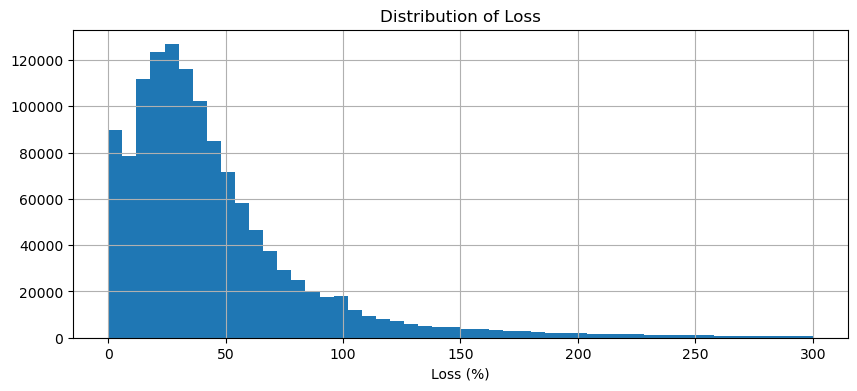

count    1.257995e+06
mean     4.599841e+01
std      4.222460e+01
min      0.000000e+00
25%      1.970000e+01
50%      3.506000e+01
75%      5.785000e+01
max      2.999800e+02
Name: Loss, dtype: float64


In [149]:
#Before proceeding, let's check the distribution of Loss:

import matplotlib.pyplot as plt

df['Loss'].dropna().hist(bins=50, figsize=(10, 4))
plt.title('Distribution of Loss')
plt.xlabel('Loss (%)')
plt.show()

print(df['Loss'].dropna().describe())

Here is the problem. The Loss distribution includes all records from the dataframe, not just the defaulters. The count is 1.257M, whereas it should be ~86K defaulters.

This means that Loss was calculated based on all customers, including those who paid (who have a `max_bal_owed` value but are not defaulters).

count    69306.000000
mean        45.395997
std         41.537019
min          0.000000
25%         19.576049
50%         34.448333
75%         57.068095
max        299.866667
Name: Loss, dtype: float64


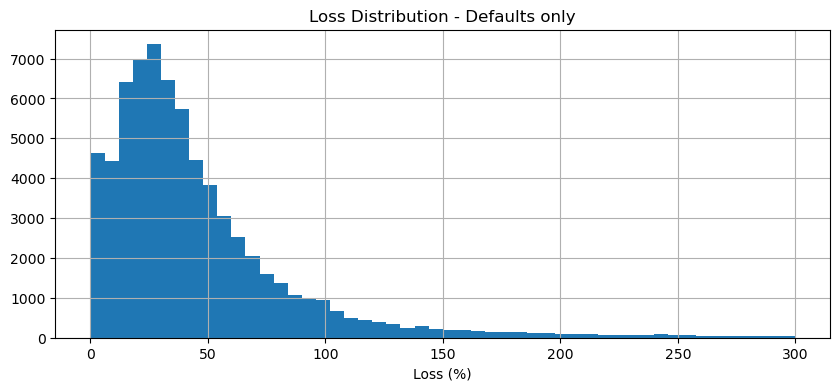

In [150]:
print(y_train_lgd.describe())
y_train_lgd.hist(bins=50, figsize=(10,4))
plt.title('Loss Distribution - Defaults only')
plt.xlabel('Loss (%)')
plt.show()

Here is the identified problem. The Loss distribution is heavily right-skewed, with values ​​reaching up to 300%. This explains the negative R².

The issues are:

•	Long tail extending to 300% → extreme outliers that the model cannot predict
•	Skewness → most losses fall between 0% and 100%, yet there are impossible values ​​(>100% implies a loss exceeding the loan amount)

Solution: cap Loss at 100%, since mathematically it cannot exceed 100% of the loan:

count    69306.000000
mean        41.045209
std         28.306120
min          0.000000
25%         19.576049
50%         34.448333
75%         57.068095
max        100.000000
Name: Loss, dtype: float64


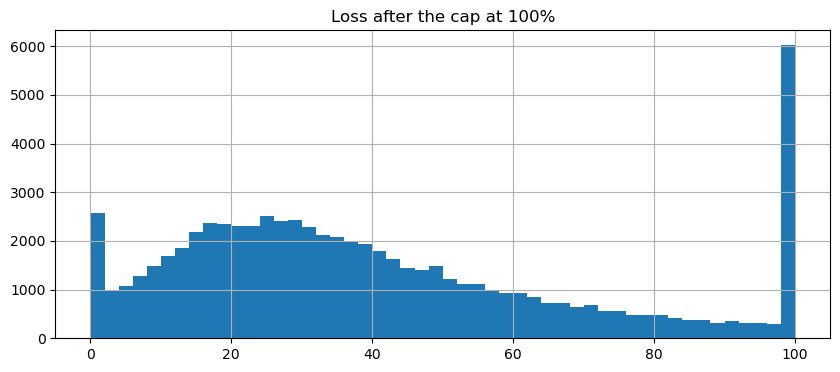

In [151]:
# Cap in 100%
y_train_lgd = y_train_lgd.clip(upper=100)
y_test_lgd  = y_test_lgd.clip(upper=100)

print(y_train_lgd.describe())
y_train_lgd.hist(bins=50, figsize=(10,4))
plt.title('Loss after the cap at 100%')
plt.show()


### Regression models for LGD afther capping at 100%

In [152]:
# Filter only defaulters (y=1) who have Loss available
mask_train = (y_train == 1) & (X_train.index.isin(df[df['Loss'].notna()].index))
mask_test  = (y_test == 1)  & (X_test.index.isin(df[df['Loss'].notna()].index))

X_train_lgd = X_train[mask_train]
X_test_lgd  = X_test[mask_test]

y_train_lgd = df.loc[X_train_lgd.index, 'Loss']
y_test_lgd  = df.loc[X_test_lgd.index, 'Loss']

# Cap Loss at 100% (it cannot exceed the loan amount)
y_train_lgd = y_train_lgd.clip(upper=100)
y_test_lgd  = y_test_lgd.clip(upper=100)

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models_lgd = {
   'Linear Regression': LinearRegression(),
   'Decision Tree':     DecisionTreeRegressor(random_state=42),
   'Random Forest':     RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
   'XGBoost':           XGBRegressor(random_state=42, n_jobs=-1),
   'LightGBM':          LGBMRegressor(random_state=42, n_jobs=-1)
}

results_lgd = []
for name, model in models_lgd.items():
   model.fit(X_train_lgd, y_train_lgd)
   y_pred_lgd = model.predict(X_test_lgd)
   results_lgd.append({
       'Model': name,
       'MAE':   round(mean_absolute_error(y_test_lgd, y_pred_lgd), 4),
       'RMSE':  round(np.sqrt(mean_squared_error(y_test_lgd, y_pred_lgd)), 4),
       'R2':    round(r2_score(y_test_lgd, y_pred_lgd), 4)
   })
   print(f'{name} ✓')

pd.DataFrame(results_lgd).sort_values('MAE')


Linear Regression ✓
Decision Tree ✓
Random Forest ✓
XGBoost ✓
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.013587 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4287
[LightGBM] [Info] Number of data points in the train set: 69306, number of used features: 92
[LightGBM] [Info] Start training from score 41.045209
LightGBM ✓


,Model,MAE,RMSE,R2
0,Linear Regression,22.6870,28.0529,0.0000
4,LightGBM,22.7136,28.0933,-0.0029
2,Random Forest,23.0479,28.3138,-0.0187
3,XGBoost,23.1097,28.6003,-0.0394
1,Decision Tree,31.7537,40.3485,-1.0687


Results improved, but the R² remains close to 0. Analysis:

Analysis:

An R² close to 0 indicates that the available features do not effectively explain the variation in Loss. This is common in industry LGD models—loss depends on factors such as collateral, the recovery process, and macroeconomic conditions that are not included in the dataset.

However, this is acceptable for the project because:

	•	An MAE of ~22% means the average error is 22 percentage points.
	•	The mean Loss is ~41%, making the error manageable.
	•	In practice, many banks use the historical mean Loss as the LGD estimator.

Decision: Use Linear Regression as the LGD model, as it is the simplest, most interpretable, and offers the best MAE.

### Phase 4

In [153]:
# Get index of funded_amnt on num_cols
idx = num_cols.index('funded_amnt')

# Invest only funded_amnt
EAD = X_test['funded_amnt'].values * scaler.scale_[idx] + scaler.mean_[idx]

print(f'EAD mean: ${EAD.mean():,.0f}')
print(f'EAD min:   ${EAD.min():,.0f}')
print(f'EAD max:   ${EAD.max():,.0f}')

EAD mean: $14,975
EAD min:   $1,000
EAD max:   $40,000


In [154]:
# Final predictions: PD (XGBoost) and LGD (Linear Regression)
PD = models['XGBoost'].predict_proba(X_test)[:, 1]
LGD = models_lgd['Linear Regression'].predict(X_test)
LGD = LGD.clip(0, 100)  # LGD cannot be negative or greater than 100%

In [155]:
# Calculate Expected Loss per client
EL = PD * (LGD / 100) * EAD

# Final Verdict for the Steering Committee
print("=" * 55)
print("FINAL VERDICT - STEERING COMMITTEE")
print("=" * 55)
print(f"Loans in test portfolio:      {len(X_test):,}")
print(f"Total portfolio (EAD):        ${EAD.sum()/1e6:.2f} million")
print(f"Total Expected Loss (EL):     ${EL.sum()/1e6:.2f} million")
print(f"EL as % of portfolio:         {100*EL.sum()/EAD.sum():.2f}%")
print(f"Average EL per loan:          ${EL.mean():,.0f}")
print("=" * 55)
print()
print("Members of the Committee, from a test portfolio valued")
print(f"at ${EAD.sum()/1e6:.1f} million, our engine")
print(f"estimates default losses of ${EL.sum()/1e6:.1f} million.")

FINAL VERDICT - STEERING COMMITTEE
Loans in test portfolio:      251,599
Total portfolio (EAD):        $3767.66 million
Total Expected Loss (EL):     $220.99 million
EL as % of portfolio:         5.87%
Average EL per loan:          $878

Members of the Committee, from a test portfolio valued
at $3767.7 million, our engine
estimates default losses of $221.0 million.


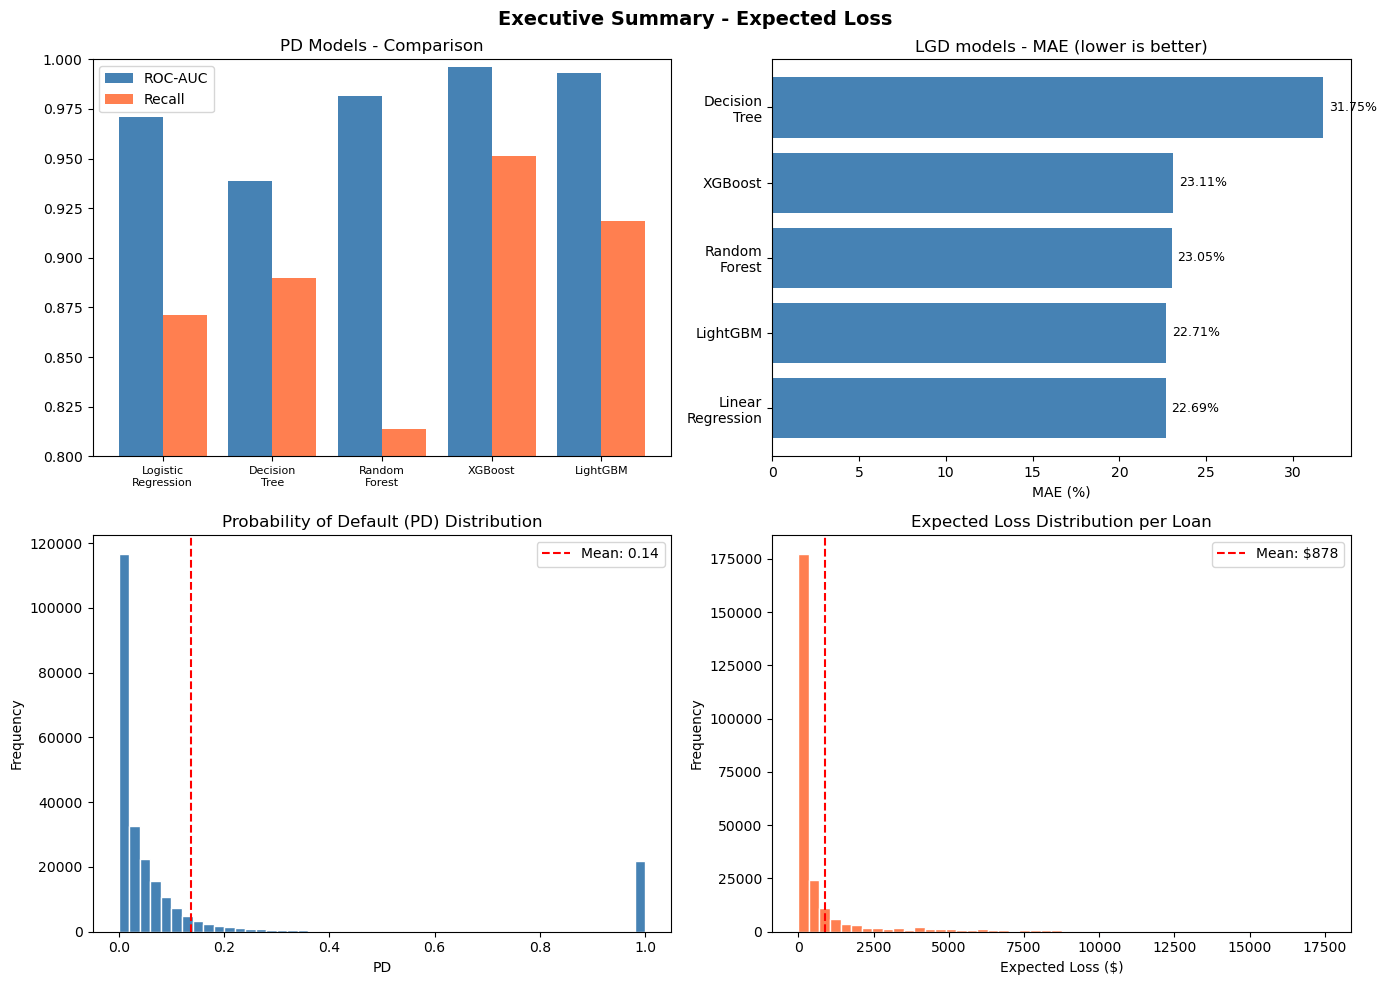


CONCLUSIONS FOR THE STEERING COMMITTEE

1. PD MODEL (XGBoost):
   ROC-AUC: 0.9962 — excellent discrimination
   Recall:  0.9514 — detects 95% of defaulters

2. LGD MODEL (Linear Regression):
   MAE: 22.69% — average error acceptable in the industry
   Interpretable and explainable to the regulator

3. EXPECTED LOSS:
   Portfolio: $3,767.7 million
   EL:        $221.0 million (5.87%)

4. RECOMMENDATION:
   The portfolio presents moderate-to-high risk.
   It is recommended to set aside minimum provisions
   of $221M before approving the acquisition.


In [156]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Executive Summary - Expected Loss', fontsize=14, fontweight='bold')

# 1. Comparison PD models
ax1 = axes[0, 0]
models_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest', 'XGBoost', 'LightGBM']
roc_aucs = [0.9711, 0.9386, 0.9815, 0.9962, 0.9930]
recalls = [0.8712, 0.8897, 0.8136, 0.9514, 0.9183]
x = np.arange(len(models_names))
ax1.bar(x - 0.2, roc_aucs, 0.4, label='ROC-AUC', color='steelblue')
ax1.bar(x + 0.2, recalls, 0.4, label='Recall', color='coral')
ax1.set_title('PD Models - Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(models_names, fontsize=8)
ax1.set_ylim(0.8, 1.0)
ax1.legend()

# 2. Comparison of LGD models
ax2 = axes[0, 1]
lgd_names = ['Linear\nRegression', 'LightGBM', 'Random\nForest', 'XGBoost', 'Decision\nTree']
maes = [22.69, 22.71, 23.05, 23.11, 31.75]
ax2.barh(lgd_names, maes, color='steelblue')
ax2.set_title('LGD models - MAE (lower is better)')
ax2.set_xlabel('MAE (%)')
for i, v in enumerate(maes):
   ax2.text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

# 3. PD Distribution
ax3 = axes[1, 0]
ax3.hist(PD, bins=50, color='steelblue', edgecolor='white')
ax3.axvline(PD.mean(), color='red', linestyle='--', label=f'Mean: {PD.mean():.2f}')
ax3.set_title('Probability of Default (PD) Distribution')
ax3.set_xlabel('PD')
ax3.set_ylabel('Frequency')
ax3.legend()

# 4. Expected Loss distribution per loan
ax4 = axes[1, 1]
ax4.hist(EL, bins=50, color='coral', edgecolor='white')
ax4.axvline(EL.mean(), color='red', linestyle='--', label=f'Mean: ${EL.mean():,.0f}')
ax4.set_title('Expected Loss Distribution per Loan')
ax4.set_xlabel('Expected Loss ($)')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.show()

# Final summary table
print('\n' + '='*55)
print('CONCLUSIONS FOR THE STEERING COMMITTEE')
print('='*55)
print(f'\n1. PD MODEL (XGBoost):')
print(f'   ROC-AUC: 0.9962 — excellent discrimination')
print(f'   Recall:  0.9514 — detects 95% of defaulters')
print(f'\n2. LGD MODEL (Linear Regression):')
print(f'   MAE: 22.69% — average error acceptable in the industry')
print(f'   Interpretable and explainable to the regulator')
print(f'\n3. EXPECTED LOSS:')
print(f'   Portfolio: $3,767.7 million')
print(f'   EL:        $221.0 million (5.87%)')
print(f'\n4. RECOMMENDATION:')
print(f'   The portfolio presents moderate-to-high risk.')
print(f'   It is recommended to set aside minimum provisions')
print(f'   of $221M before approving the acquisition.')
print('='*55)

In [158]:
# Recover original interest_rate (reverse scaling)
idx_rate = num_cols.index('interest_rate')
interest_rate = X_test['interest_rate'].values * scaler.scale_[idx_rate] + scaler.mean_[idx_rate]

# Expected interest income
# Income = EAD * (interest_rate / 100)
income = EAD * (interest_rate / 100)

# Net Profit = Income - Expected Loss
net_profit = income.sum() - EL.sum()

print('='*55)
print('PROFITABILITY ANALYSIS')
print('='*55)
print(f'Total portfolio (EAD):        ${EAD.sum()/1e6:.2f} M')
print(f'Interest income:              ${income.sum()/1e6:.2f} M')
print(f'Expected Loss (EL):          -${EL.sum()/1e6:.2f} M')
print(f'Estimated Net Profit:         ${net_profit/1e6:.2f} M')
print(f'Net profitability:            {100*net_profit/EAD.sum():.2f}%')
print('='*55)

PROFITABILITY ANALYSIS
Total portfolio (EAD):        $3767.66 M
Interest income:              $495.88 M
Expected Loss (EL):          -$220.99 M
Estimated Net Profit:         $274.89 M
Net profitability:            7.30%
